In [1]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

import numpy as np
import matplotlib.pyplot as plt
import xso
from xso.parscans import run_xso_parscan, avg_tail

import cariaco_obs as co
import cariaco_npzd_setups as cns          # NPZD model (replaces cariaco_baseline_setups)
import parscan_utils as pu
import parscan_plots as pp
for m in (co, cns, pu, pp):                # pick up edits without a kernel restart
    importlib.reload(m)

phyto_esd, zoo_esd = cns.phyto_esd, cns.zoo_esd
print(f'grid: {len(phyto_esd)} phyto ({phyto_esd[0]:.2g}–{phyto_esd[-1]:.0f} µm), '
      f'{len(zoo_esd)} zoo ({zoo_esd[0]:.2g}–{zoo_esd[-1]:.0f} µm)')
print(f'spec: K_sZ={cns.K_SZ}  σ={cns.SIGMA}  GGE={cns.GGE_VAL}  '
      f'm_Z={cns.M_Z}  m_Zlin={cns.M_ZLIN}  θ_opt={cns.THETA_OPT}  '
      f'fish_rate(default)={cns.FISH_RATE}')

grid: 40 phyto (0.2–200 µm), 40 zoo (2–2000 µm)
spec: K_sZ=0.23  σ=0.15  GGE=0.25  m_Z=0.1  m_Zlin=0.05  θ_opt=10.0  fish_rate(default)=0.0


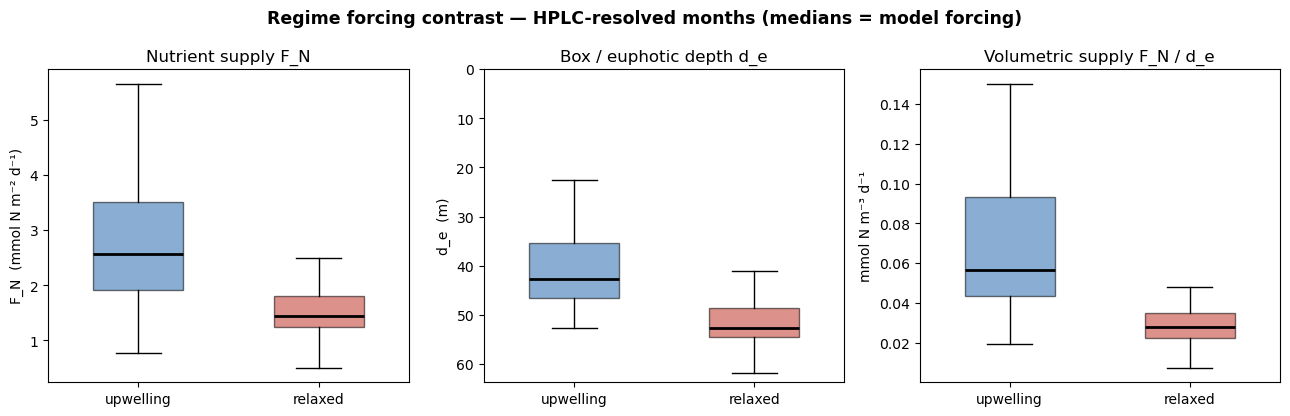

upwelling   n=31   F_N= 2.58   d_e= 42.8   T= 23.0°C   F_N/d_e=0.0603
relaxed     n=58   F_N= 1.45   d_e= 52.7   T= 25.4°C   F_N/d_e=0.0275


In [2]:
# ── Cell 4 — regime forcing (upwelling vs relaxed, HPLC months, +temperature) ─
regimes = ('upwelling', 'relaxed')

targets = {}
for r in regimes:
    obs_vec, labels, bin_defs, monthly_df, forcing = co.load_cariaco_targets(
        regime=r, months='hplc', agg='median', include_temperature=True)
    targets[r] = dict(obs_vec=obs_vec, monthly_df=monthly_df, forcing=forcing)

fig = pp.plot_regime_forcing({r: targets[r]['monthly_df'] for r in regimes},
                             regimes=regimes)
plt.show()

for r in regimes:
    f = targets[r]['forcing']
    print(f"{r:10s}  n={len(targets[r]['monthly_df']):2d}   "
          f"F_N={f['Inflow__FN']:5.2f}   d_e={f['Inflow__de']:5.1f}   "
          f"T={f.get('Temperature__value', float('nan')):5.1f}°C   "
          f"F_N/d_e={f['Inflow__FN']/f['Inflow__de']:.4f}")

upwelling   CV(ΣP)=0.020   mcs model/obs = 5.20 / 4.84 µm
            model  Pico (<2 µm)=0.46  Nano (2-20 µm)=0.16  Micro (>20 µm)=0.38
            obs    Pico (<2 µm)=0.45  Nano (2-20 µm)=0.22  Micro (>20 µm)=0.31
            ΣZ gt200 model=0.014 / obs=0.083 mmolN m⁻³  (m/o=0.17)
            ΣZ gt500 model=0.003 / obs=0.051 mmolN m⁻³  (m/o=0.05)
relaxed     CV(ΣP)=0.008   mcs model/obs = 2.95 / 2.01 µm
            model  Pico (<2 µm)=0.54  Nano (2-20 µm)=0.24  Micro (>20 µm)=0.22
            obs    Pico (<2 µm)=0.61  Nano (2-20 µm)=0.26  Micro (>20 µm)=0.10
            ΣZ gt200 model=0.003 / obs=0.048 mmolN m⁻³  (m/o=0.06)
            ΣZ gt500 model=0.000 / obs=0.023 mmolN m⁻³  (m/o=0.00)


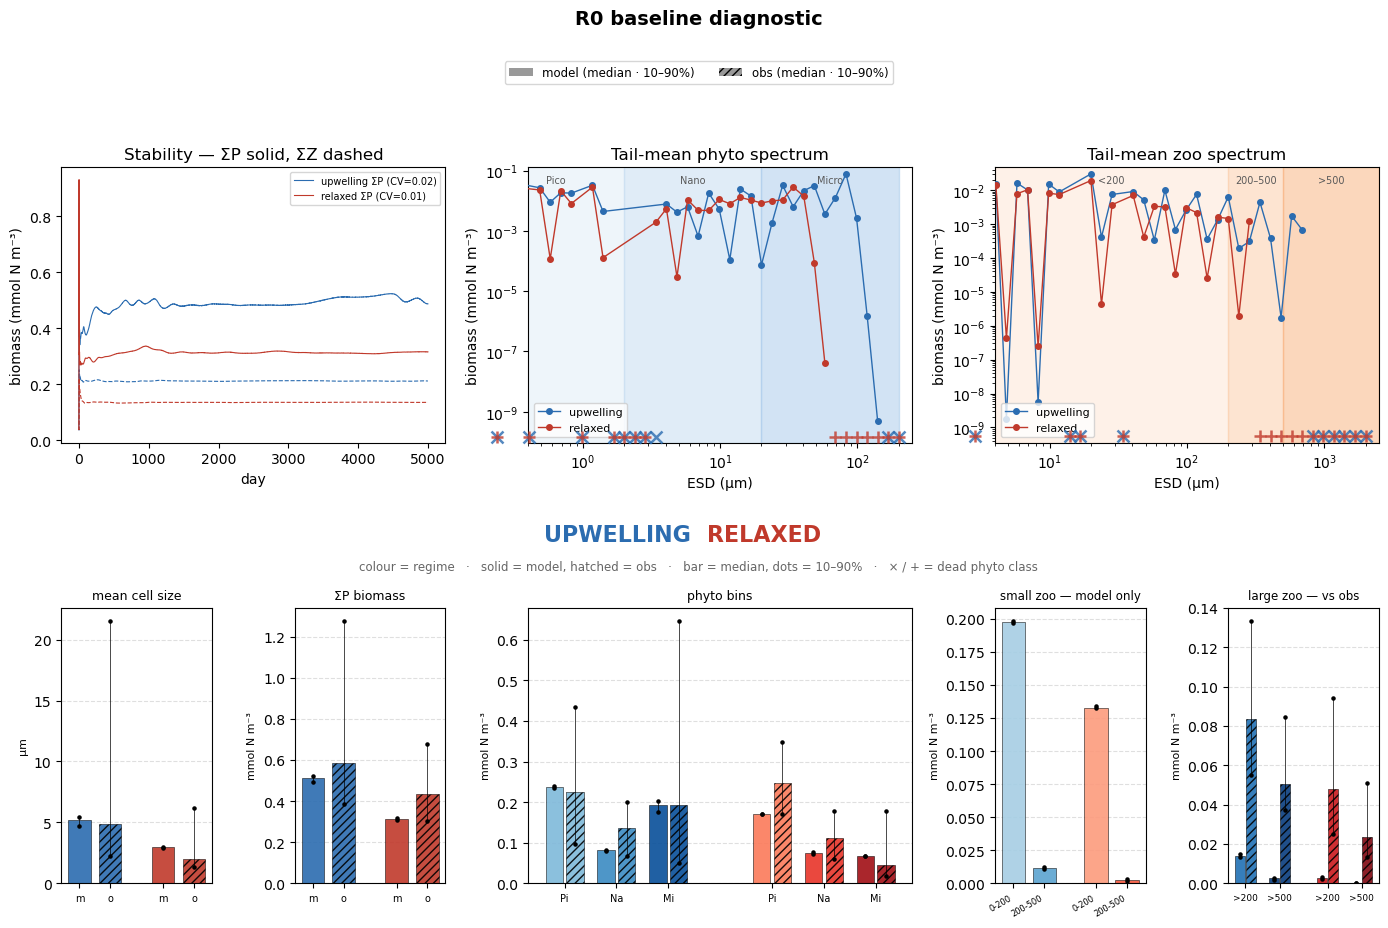

In [3]:
# ── Cell 5 — IVP per regime → tail-mean diagnostic vs obs (latest construct) ──
# Taniguchi growth + Ward 0.02 uniform mortality + Dutkiewicz Type III (K_sZ=0.23 default)
TAIL = 1000
mP_ward = np.full(len(phyto_esd), 0.02)          # the open mortality lever; swap to test others

def _bin_frac_model(proc):
    pb = np.asarray(proc['phyto_bins_tail'])
    fr = pb / np.clip(pb.sum(axis=0, keepdims=True), 1e-12, None)
    return np.nanmedian(fr, axis=1), proc['phyto_bin_labels']
def _bin_frac_obs(obs):
    pb = np.vstack(obs['phyto_bins'])
    fr = pb / np.clip(pb.sum(axis=0, keepdims=True), 1e-12, None)
    return np.nanmedian(fr, axis=1), obs['phyto_bin_labels']

model_by_regime, obs_by_regime = {}, {}
for r in regimes:
    out = pu.run_single_point(cns.model_npzd, cns.model_setup_npzd_tani,   # <- Taniguchi growth setup
                              scan_params={},
                              fixed_overrides={**targets[r]['forcing'],
                                               'PhytoMortality__rate': mP_ward})   # <- Ward 0.02 mortality
    model_by_regime[r] = pu.process_regime_run(out, phyto_esd, zoo_esd, bin_defs, tail_len=TAIL)
    obs_by_regime[r]   = pu.process_regime_obs(targets[r]['monthly_df'], bin_defs)
    m_mcs = np.nanmedian(model_by_regime[r]['mcs_tail'])
    o_mcs = np.nanmedian(obs_by_regime[r]['mcs'])
    mfr, mlab = _bin_frac_model(model_by_regime[r])
    ofr, olab = _bin_frac_obs(obs_by_regime[r])
    print(f"{r:10s}  CV(ΣP)={model_by_regime[r]['cv']:.3f}   "
          f"mcs model/obs = {m_mcs:.2f} / {o_mcs:.2f} µm")
    print("            model  " + "  ".join(f"{l}={v:.2f}" for l, v in zip(mlab, mfr)))
    print("            obs    " + "  ".join(f"{l}={v:.2f}" for l, v in zip(olab, ofr)))
    # ── Large-Z diagnostic — Z>200µm and Z>500µm (the two data-constrained bands)
    # Caveat: obs zoo bongo-tows integrate 0–200 m, NOT the model's euphotic box;
    # absolute m/o ratios carry a known depth-mismatch systematic — read shapes, not levels.
    for thr_key, obs_label in [('gt200', 'Zoo >200 µm'), ('gt500', 'Zoo >500 µm')]:
        mZ = np.nanmedian(model_by_regime[r]['zoo_cum_tail'][thr_key])
        oZv = obs_by_regime[r]['zoo'].get(obs_label, np.array([]))
        oZ = np.nanmedian(oZv) if len(oZv) else np.nan
        ratio = mZ / oZ if (np.isfinite(oZ) and oZ > 0) else np.nan
        print(f"            ΣZ {thr_key:5s} model={mZ:.3f} / obs={oZ:.3f} mmolN m⁻³  (m/o={ratio:.2f})")

fig = pp.plot_regime_diagnostic(model_by_regime, obs_by_regime,
                                phyto_esd, zoo_esd, regimes=regimes)
plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 16 points using 8 workers...
1D Scan complete. Time taken: 19.80862 seconds.

=== UPWELLING  (F_N=2.58, d_e=42.8) ===
   r_F    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D
 0.000   5.11   0.237   0.081   0.191   0.509  0.0141  0.0024   0.211   0.084   0.497
 0.067   4.48   0.234   0.082   0.163   0.479  0.0091  0.0000   0.208   0.085   0.488
 0.133   5.00   0.232   0.091   0.181   0.504  0.0072  0.0000   0.203   0.084   0.480
 0.200   4.48   0.233   0.095   0.160   0.488  0.0063  0.0000   0.199   0.082   0.474
 0.267   4.21   0.232   0.094   0.149   0.474  0.0040  0.0000   0.197   0.082   0.469
 0.333   3.98   0.230   0.102   0.137   0.469  0.0038  0.0000 

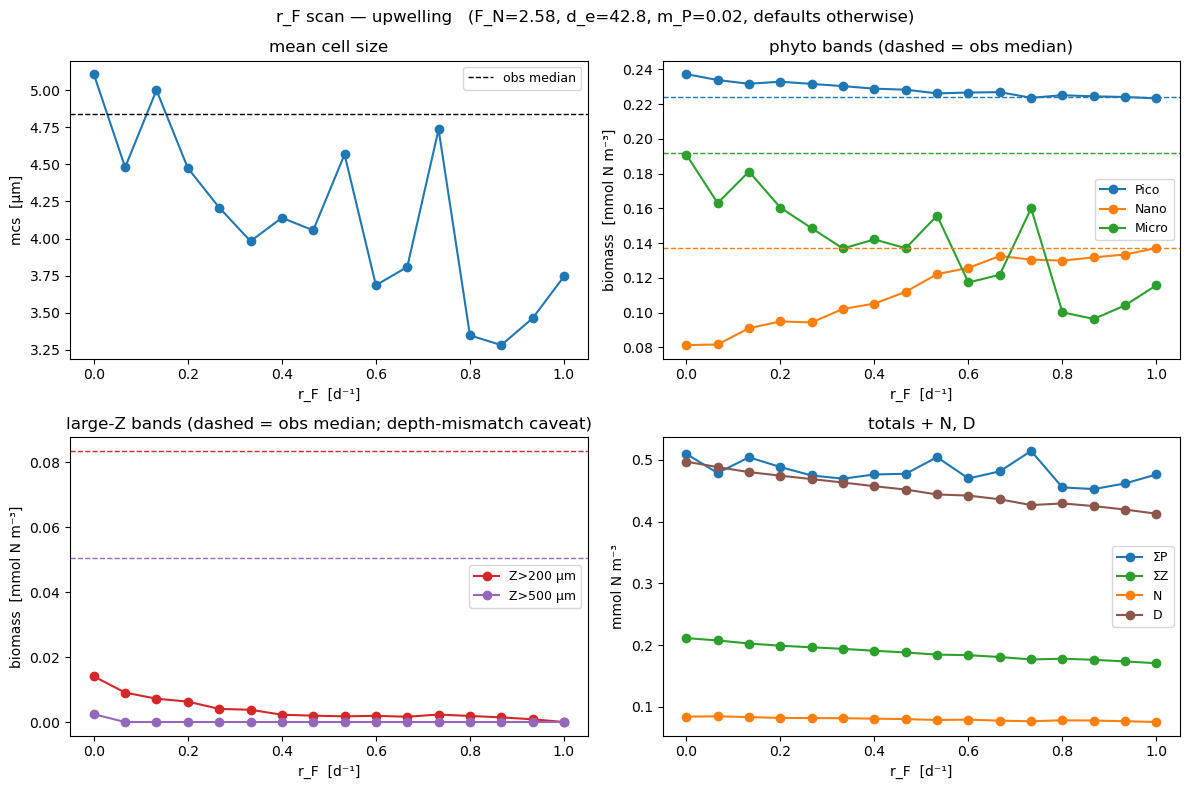

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 16 points using 8 workers...
1D Scan complete. Time taken: 15.91389 seconds.

=== RELAXED  (F_N=1.45, d_e=52.7) ===
   r_F    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D
 0.000   2.94   0.171   0.074   0.068   0.313  0.0027  0.0000   0.136   0.046   0.280
 0.067   2.92   0.171   0.083   0.065   0.319  0.0011  0.0000   0.132   0.045   0.275
 0.133   3.02   0.169   0.088   0.066   0.323  0.0023  0.0000   0.130   0.044   0.270
 0.200   2.67   0.168   0.087   0.053   0.308  0.0007  0.0000   0.128   0.044   0.266
 0.267   2.45   0.169   0.091   0.044   0.304  0.0006  0.0000   0.126   0.044   0.262
 0.333   2.38   0.169   0.099   0.039   0.307  0.0000  0.0000   

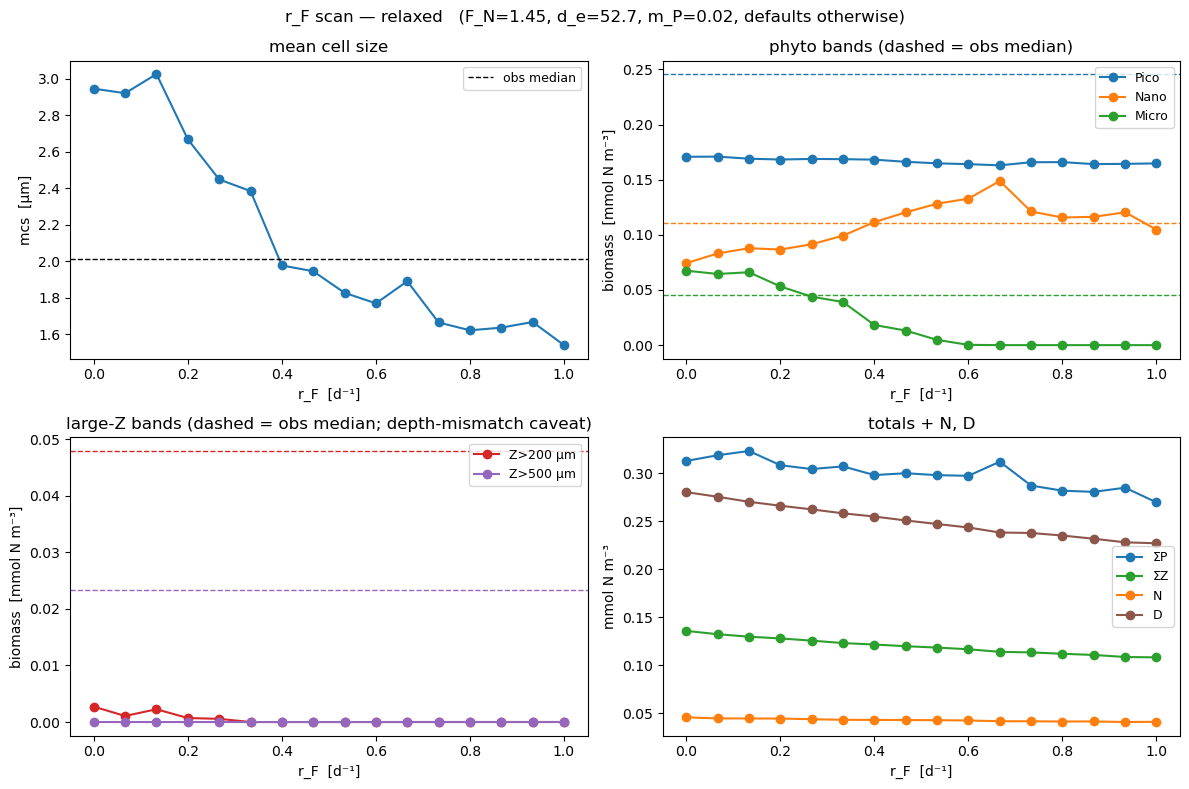

In [7]:
# ── Cell 6 — r_F (fish grazing) parscan per regime ─────────────────────────────
# Baseline: Taniguchi growth + uniform m_P = 0.02 + omnivory + Type III + closure default
# Scans FishGrazing__rate ∈ [0, 1] d⁻¹ at observed regime forcing.
# CV is NOT returned by avg_tail — verify stability at any flagged r_F separately.
# mcs and Pico/Nano/Micro use Sieburth log-overlap weights × bin geomeans
# (same path as aggregate_model_to_targets / process_regime_run; like-for-like with obs).
from xso.parscans import run_xso_parscan
from parscan_utils import (get_log_bin_edges, get_fraction_in_range,
                           CARIACO_PHYTO_BIN_GEOMEANS)

RF_VALUES = np.linspace(0.0, 1.0, 16)
TAIL_AVG  = 1000
mP_baseline = np.full(len(phyto_esd), 0.02)

# Sieburth bin weights for the model phyto grid (computed once)
_p_edges  = get_log_bin_edges(np.asarray(phyto_esd))
_SIEBURTH = [(0.0, 2.0), (2.0, 20.0), (20.0, np.inf)]    # Pico, Nano, Micro
W_phyto = np.array([
    [get_fraction_in_range(_p_edges[i], _p_edges[i + 1], lo, hi)
     for i in range(len(phyto_esd))]
    for (lo, hi) in _SIEBURTH
])                                                       # shape (3, n_P)
GEOMEANS = CARIACO_PHYTO_BIN_GEOMEANS                    # [0.63, 6.3, 63.0]

# Zoo cumulative-band masks — unchanged (already obs-aligned cumulative >threshold)
m_z200 = zoo_esd > 200.0
m_z500 = zoo_esd > 500.0

rf_scans = {}
for r in regimes:
    overrides = {**targets[r]['forcing'],
                 'PhytoMortality__rate': mP_baseline}
    scan = run_xso_parscan(
        model_file_name='cariaco_npzd_setups',
        model_name='model_npzd',
        model_setup_name='model_setup_npzd_tani_scan',
        param_name='FishGrazing__rate',
        param_values=RF_VALUES,
        fixed_overrides=overrides,
        postprocess_name='avg_tail',
        postprocess_kwargs={'avg_window': TAIL_AVG},
        processes=8,
    )
    order = np.argsort(scan['FishGrazing__rate'].values)
    rF = scan['FishGrazing__rate'].values[order]
    P  = scan['Phytoplankton__biomass'].squeeze('time').values[order]
    Z  = scan['Zooplankton__biomass'].squeeze('time').values[order]
    N  = scan['Nutrient__value'].squeeze('time').values[order]
    D  = scan['Detritus__value'].squeeze('time').values[order]

    sumP = P.sum(axis=1); sumZ = Z.sum(axis=1)
    # Sieburth bin biomass via log-overlap weights — aligned with obs side
    bins_model = P @ W_phyto.T                           # shape (n_rF, 3)
    P_pico, P_nano, P_micro = bins_model[:, 0], bins_model[:, 1], bins_model[:, 2]
    frac_bins = bins_model / np.maximum(bins_model.sum(axis=1, keepdims=True), 1e-30)
    mcs = 10.0 ** (frac_bins @ np.log10(GEOMEANS))       # bin-geomean mcs [µm]
    Z_gt200 = Z[:, m_z200].sum(axis=1)
    Z_gt500 = Z[:, m_z500].sum(axis=1)

    rf_scans[r] = dict(rF=rF, sumP=sumP, sumZ=sumZ, N=N, D=D, mcs=mcs,
                       P_pico=P_pico, P_nano=P_nano, P_micro=P_micro,
                       Z_gt200=Z_gt200, Z_gt500=Z_gt500)

    # ── obs reference values (per-month medians) ───────────────────────────
    obs = obs_by_regime[r]
    o_mcs   = float(np.nanmedian(obs['mcs']))
    o_pico  = float(np.nanmedian(obs['phyto_bins'][0]))
    o_nano  = float(np.nanmedian(obs['phyto_bins'][1]))
    o_micro = float(np.nanmedian(obs['phyto_bins'][2]))
    o_sumP  = float(np.nanmedian(obs['sumP']))
    o_z200v = obs['zoo'].get('Zoo >200 µm', np.array([]))
    o_z500v = obs['zoo'].get('Zoo >500 µm', np.array([]))
    o_z200  = float(np.nanmedian(o_z200v)) if len(o_z200v) else np.nan
    o_z500  = float(np.nanmedian(o_z500v)) if len(o_z500v) else np.nan

    # ── full-scan diagnostic print (every r_F row) ─────────────────────────
    print(f"\n=== {r.upper()}  (F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
          f"d_e={targets[r]['forcing']['Inflow__de']:.1f}) ===")
    print(f"{'r_F':>6} {'mcs':>6} {'Pico':>7} {'Nano':>7} {'Micro':>7} "
          f"{'ΣP':>7} {'Z>200':>7} {'Z>500':>7} {'ΣZ':>7} "
          f"{'N':>7} {'D':>7}")
    for i in range(len(rF)):
        print(f"{rF[i]:6.3f} {mcs[i]:6.2f} {P_pico[i]:7.3f} {P_nano[i]:7.3f} "
              f"{P_micro[i]:7.3f} {sumP[i]:7.3f} {Z_gt200[i]:7.4f} "
              f"{Z_gt500[i]:7.4f} {sumZ[i]:7.3f} {N[i]:7.3f} {D[i]:7.3f}")
    print(f"{'obs':>6} {o_mcs:6.2f} {o_pico:7.3f} {o_nano:7.3f} "
          f"{o_micro:7.3f} {o_sumP:7.3f} {o_z200:7.4f} {o_z500:7.4f} "
          f"{'-':>7} {'-':>7} {'-':>7}")

    # ── per-regime 4-panel plot (linear axes) ──────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"r_F scan — {r}   "
                 f"(F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
                 f"d_e={targets[r]['forcing']['Inflow__de']:.1f}, "
                 f"m_P=0.02, defaults otherwise)")

    ax = axes[0, 0]
    ax.plot(rF, mcs, '-o', color='C0')
    ax.axhline(o_mcs, color='k', ls='--', lw=1, label='obs median')
    ax.set_xlabel('r_F  [d⁻¹]'); ax.set_ylabel('mcs  [µm]')
    ax.set_title('mean cell size'); ax.legend(fontsize=9)

    ax = axes[0, 1]
    ax.plot(rF, P_pico,  '-o', color='C0', label='Pico')
    ax.plot(rF, P_nano,  '-o', color='C1', label='Nano')
    ax.plot(rF, P_micro, '-o', color='C2', label='Micro')
    ax.axhline(o_pico,  color='C0', ls='--', lw=1)
    ax.axhline(o_nano,  color='C1', ls='--', lw=1)
    ax.axhline(o_micro, color='C2', ls='--', lw=1)
    ax.set_xlabel('r_F  [d⁻¹]'); ax.set_ylabel('biomass  [mmol N m⁻³]')
    ax.set_title('phyto bands (dashed = obs median)'); ax.legend(fontsize=9)

    ax = axes[1, 0]
    ax.plot(rF, Z_gt200, '-o', color='C3', label='Z>200 µm')
    ax.plot(rF, Z_gt500, '-o', color='C4', label='Z>500 µm')
    ax.axhline(o_z200, color='C3', ls='--', lw=1)
    ax.axhline(o_z500, color='C4', ls='--', lw=1)
    ax.set_xlabel('r_F  [d⁻¹]'); ax.set_ylabel('biomass  [mmol N m⁻³]')
    ax.set_title('large-Z bands (dashed = obs median; depth-mismatch caveat)')
    ax.legend(fontsize=9)

    ax = axes[1, 1]
    ax.plot(rF, sumP, '-o', color='C0', label='ΣP')
    ax.plot(rF, sumZ, '-o', color='C2', label='ΣZ')
    ax.plot(rF, N,    '-o', color='C1', label='N')
    ax.plot(rF, D,    '-o', color='C5', label='D')
    ax.set_xlabel('r_F  [d⁻¹]'); ax.set_ylabel('mmol N m⁻³')
    ax.set_title('totals + N, D'); ax.legend(fontsize=9)

    plt.tight_layout(); plt.show()


=== UPWELLING  r_F = 0.2  (F_N=2.58, d_e=42.8) ===
Total fish loss        :   0.0029 mmol N m⁻³ d⁻¹
  on phyto             :   0.0017  ( 59.7% of total)
    Pico (<2 µm)       :   0.0006  ( 34.1% of P loss)
    Nano (2-20 µm)     :   0.0003  ( 17.1% of P loss)
    Micro (>20 µm)     :   0.0008  ( 48.8% of P loss)
  on zoo               :   0.0012  ( 40.3% of total)
    Z (≤200 µm)        :   0.0009  ( 73.7% of Z loss)
    Z (200-500 µm)     :   0.0003  ( 26.3% of Z loss)
    Z (>500 µm)        :   0.0000  (  0.0% of Z loss)


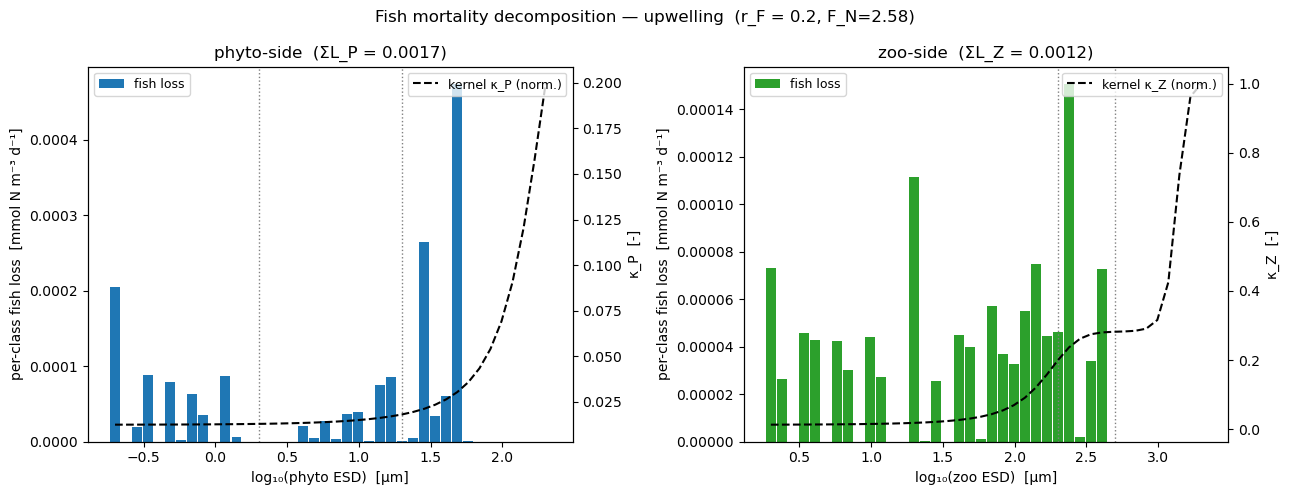


=== RELAXED  r_F = 0.2  (F_N=1.45, d_e=52.7) ===
Total fish loss        :   0.0014 mmol N m⁻³ d⁻¹
  on phyto             :   0.0009  ( 62.8% of total)
    Pico (<2 µm)       :   0.0004  ( 46.9% of P loss)
    Nano (2-20 µm)     :   0.0003  ( 29.5% of P loss)
    Micro (>20 µm)     :   0.0002  ( 23.6% of P loss)
  on zoo               :   0.0005  ( 37.2% of total)
    Z (≤200 µm)        :   0.0005  ( 94.7% of Z loss)
    Z (200-500 µm)     :   0.0000  (  5.3% of Z loss)
    Z (>500 µm)        :   0.0000  (  0.0% of Z loss)


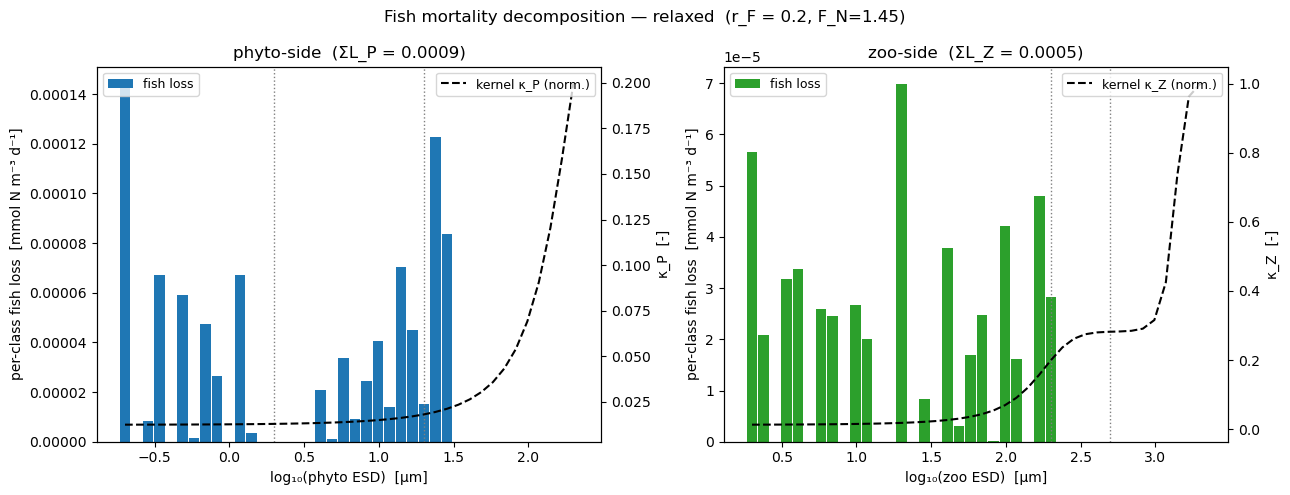

In [8]:
# ── Cell 7 — fish mortality decomposition ────────────────────────────────────
# At a chosen r_F, decompose the Rykaczewski kernel's action by size class:
#   per-class L = r_F · κ · B_tail  on both phyto and zoo grids.
# Tells us who actually gets grazed by fish and what share goes to direct
# phyto cropping vs zoo cropping.
from cariaco_npzd_setups import kernel_P_fish, kernel_Z_fish
from parscan_utils import (get_log_bin_edges, get_fraction_in_range,
                           CARIACO_PHYTO_BIN_GEOMEANS)

R_F_DIAGNOSTIC = 0.2
TAIL_FISH      = 1000
mP_baseline = np.full(len(phyto_esd), 0.02)

# Sieburth phyto-band weights (same construction as Cell 6)
_p_edges  = get_log_bin_edges(np.asarray(phyto_esd))
_SIEBURTH = [(0.0, 2.0), (2.0, 20.0), (20.0, np.inf)]
W_phyto = np.array([
    [get_fraction_in_range(_p_edges[i], _p_edges[i + 1], lo, hi)
     for i in range(len(phyto_esd))]
    for (lo, hi) in _SIEBURTH
])

dlog_p = np.diff(np.log10(phyto_esd))[0] * 0.9
dlog_z = np.diff(np.log10(zoo_esd))[0]   * 0.9

for r in regimes:
    overrides = {**targets[r]['forcing'],
                 'PhytoMortality__rate': mP_baseline,
                 'FishGrazing__rate':    R_F_DIAGNOSTIC}
    out = pu.run_single_point(cns.model_npzd, cns.model_setup_npzd_tani,
                              scan_params={}, fixed_overrides=overrides)

    P_tail = out['Phytoplankton__biomass'].isel(time=slice(-TAIL_FISH, None))\
              .mean('time').values
    Z_tail = out['Zooplankton__biomass'].isel(time=slice(-TAIL_FISH, None))\
              .mean('time').values

    # per-class fish loss [mmol N m-3 d-1]
    L_P = R_F_DIAGNOSTIC * kernel_P_fish * P_tail
    L_Z = R_F_DIAGNOSTIC * kernel_Z_fish * Z_tail
    tot_P, tot_Z = float(L_P.sum()), float(L_Z.sum())
    tot          = tot_P + tot_Z
    safe = lambda v, d: 100 * v / d if d > 0 else 0.0

    # phyto fish loss by Sieburth band (log-overlap weights)
    L_P_pico  = float((W_phyto[0] * L_P).sum())
    L_P_nano  = float((W_phyto[1] * L_P).sum())
    L_P_micro = float((W_phyto[2] * L_P).sum())

    # zoo fish loss by data-aligned bands
    L_Z_lt200 = float(L_Z[zoo_esd <= 200.0].sum())
    L_Z_200_500 = float(L_Z[(zoo_esd > 200.0) & (zoo_esd <= 500.0)].sum())
    L_Z_gt500 = float(L_Z[zoo_esd > 500.0].sum())

    print(f"\n=== {r.upper()}  r_F = {R_F_DIAGNOSTIC}  "
          f"(F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
          f"d_e={targets[r]['forcing']['Inflow__de']:.1f}) ===")
    print(f"Total fish loss        : {tot:8.4f} mmol N m⁻³ d⁻¹")
    print(f"  on phyto             : {tot_P:8.4f}  ({safe(tot_P, tot):5.1f}% of total)")
    print(f"    Pico (<2 µm)       : {L_P_pico:8.4f}  ({safe(L_P_pico,  tot_P):5.1f}% of P loss)")
    print(f"    Nano (2-20 µm)     : {L_P_nano:8.4f}  ({safe(L_P_nano,  tot_P):5.1f}% of P loss)")
    print(f"    Micro (>20 µm)     : {L_P_micro:8.4f}  ({safe(L_P_micro, tot_P):5.1f}% of P loss)")
    print(f"  on zoo               : {tot_Z:8.4f}  ({safe(tot_Z, tot):5.1f}% of total)")
    print(f"    Z (≤200 µm)        : {L_Z_lt200:8.4f}  ({safe(L_Z_lt200,   tot_Z):5.1f}% of Z loss)")
    print(f"    Z (200-500 µm)     : {L_Z_200_500:8.4f}  ({safe(L_Z_200_500, tot_Z):5.1f}% of Z loss)")
    print(f"    Z (>500 µm)        : {L_Z_gt500:8.4f}  ({safe(L_Z_gt500,   tot_Z):5.1f}% of Z loss)")

    # ── 2-panel bar chart (linear axes; log10(ESD) on x-axis) ────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"Fish mortality decomposition — {r}  "
                 f"(r_F = {R_F_DIAGNOSTIC}, F_N={targets[r]['forcing']['Inflow__FN']:.2f})")

    ax = axes[0]
    ax.bar(np.log10(phyto_esd), L_P, width=dlog_p, color='C0',
           label='fish loss')
    axk = ax.twinx()
    axk.plot(np.log10(phyto_esd), kernel_P_fish, 'k--', lw=1.5,
             label='kernel κ_P (norm.)')
    for x in (np.log10(2.0), np.log10(20.0)):
        ax.axvline(x, color='gray', ls=':', lw=1)
    ax.set_xlabel('log₁₀(phyto ESD)  [µm]')
    ax.set_ylabel('per-class fish loss  [mmol N m⁻³ d⁻¹]')
    axk.set_ylabel('κ_P  [-]')
    ax.set_title(f'phyto-side  (ΣL_P = {tot_P:.4f})')
    ax.legend(loc='upper left', fontsize=9); axk.legend(loc='upper right', fontsize=9)

    ax = axes[1]
    ax.bar(np.log10(zoo_esd), L_Z, width=dlog_z, color='C2',
           label='fish loss')
    axk = ax.twinx()
    axk.plot(np.log10(zoo_esd), kernel_Z_fish, 'k--', lw=1.5,
             label='kernel κ_Z (norm.)')
    for x in (np.log10(200.0), np.log10(500.0)):
        ax.axvline(x, color='gray', ls=':', lw=1)
    ax.set_xlabel('log₁₀(zoo ESD)  [µm]')
    ax.set_ylabel('per-class fish loss  [mmol N m⁻³ d⁻¹]')
    axk.set_ylabel('κ_Z  [-]')
    ax.set_title(f'zoo-side  (ΣL_Z = {tot_Z:.4f})')
    ax.legend(loc='upper left', fontsize=9); axk.legend(loc='upper right', fontsize=9)

    plt.tight_layout(); plt.show()

In [9]:
# ── Helper cell — diagnostic extraction + table + 6-panel plot ───────────────
# Reusable across all parameter scans. Expects full-output parscan datasets
# (model_setup_npzd_tani — NOT _scan), so PP (Growth__uptake_value) and
# Export (DetritusSink__sinking_value) are available.
import numpy as np
import matplotlib.pyplot as plt
from parscan_utils import (get_log_bin_edges, get_fraction_in_range,
                           CARIACO_PHYTO_BIN_GEOMEANS)

# Sieburth log-overlap weights — computed once per notebook session
_p_edges  = get_log_bin_edges(np.asarray(phyto_esd))
_SIEBURTH = [(0.0, 2.0), (2.0, 20.0), (20.0, np.inf)]
W_PHYTO = np.array([
    [get_fraction_in_range(_p_edges[i], _p_edges[i + 1], lo, hi)
     for i in range(len(phyto_esd))]
    for (lo, hi) in _SIEBURTH
])
M_Z200   = zoo_esd > 200.0
M_Z500   = zoo_esd > 500.0
GEOMEANS = CARIACO_PHYTO_BIN_GEOMEANS    # [0.63, 6.3, 63.0]

# Cross-scan store — each scan cell writes `param_scans[name][regime] = metrics`
param_scans = {}


def _safe_median(series):
    v = series.dropna().values
    return float(np.nanmedian(v)) if len(v) else np.nan


def extract_scan_metrics(scan, axis_name, forcing):
    """Pull standard diagnostic arrays from a full-output parscan dataset.

    Parameters
    ----------
    scan      : xarray.Dataset returned by run_xso_parscan + avg_tail.
    axis_name : str — the parscan axis variable name (e.g. 'ZooQuadMortality__rate').
    forcing   : dict — regime forcing (needs 'Inflow__de' for areal Export).

    Returns a dict of 1-D arrays of length n_axis (sorted by axis):
        axis, mcs, P_pico, P_nano, P_micro, sumP,
        Z_gt200, Z_gt500, sumZ, N, D, PP, Export.
    """
    order = np.argsort(scan[axis_name].values)
    axis  = scan[axis_name].values[order]
    P  = scan['Phytoplankton__biomass'].squeeze('time').values[order]
    Z  = scan['Zooplankton__biomass'].squeeze('time').values[order]
    N  = scan['Nutrient__value'].squeeze('time').values[order]
    D  = scan['Detritus__value'].squeeze('time').values[order]
    PPpc    = scan['Growth__uptake_value'].squeeze('time').values[order]   # (n, n_P)
    exp_vol = scan['DetritusSink__sinking_value'].squeeze('time').values[order]  # (n,)

    sumP = P.sum(axis=1); sumZ = Z.sum(axis=1)
    bins = P @ W_PHYTO.T                                       # (n, 3)
    frac = bins / np.maximum(bins.sum(axis=1, keepdims=True), 1e-30)
    mcs  = 10.0 ** (frac @ np.log10(GEOMEANS))
    Export = exp_vol * float(forcing['Inflow__de'])            # mmol N m⁻² d⁻¹

    return dict(
        axis=axis,
        mcs=mcs,
        P_pico=bins[:, 0], P_nano=bins[:, 1], P_micro=bins[:, 2],
        sumP=sumP,
        Z_gt200=Z[:, M_Z200].sum(axis=1),
        Z_gt500=Z[:, M_Z500].sum(axis=1),
        sumZ=sumZ,
        N=N, D=D,
        PP=PPpc.sum(axis=1),
        Export=Export,
    )


def build_obs_refs(monthly_df, bin_geomeans=GEOMEANS):
    """Per-regime obs reference dict from monthly_df medians.

    Computes obs mcs from bin geomeans the same way as the model side, so
    the comparison is methodologically aligned.
    """
    P = monthly_df[['pico_mmolN', 'nano_mmolN', 'micro_mmolN']].dropna().values
    sumP_obs = P.sum(axis=1)
    frac     = P / np.maximum(sumP_obs[:, None], 1e-30)
    mcs_obs  = 10.0 ** (frac @ np.log10(bin_geomeans))
    return dict(
        mcs    = float(np.nanmedian(mcs_obs)),
        P_pico = float(np.nanmedian(P[:, 0])),
        P_nano = float(np.nanmedian(P[:, 1])),
        P_micro= float(np.nanmedian(P[:, 2])),
        sumP   = float(np.nanmedian(sumP_obs)),
        Z_gt200= _safe_median(monthly_df['zoo_gt200_mmolN']),
        Z_gt500= _safe_median(monthly_df['zoo_gt500_mmolN']),
        N      = _safe_median(monthly_df['NO3_mmolN']),
        PP     = _safe_median(monthly_df['PP_mmolN_m3_d']),
        Export = _safe_median(monthly_df['export_flux_corrected_mmolN']),
    )


def print_scan_table(metrics, obs_refs, header, axis_label='axis'):
    """Full-scan diagnostic table with an obs reference row at the bottom."""
    f3  = lambda v: f"{v:7.3f}" if np.isfinite(v) else f"{'-':>7}"
    f4  = lambda v: f"{v:7.4f}" if np.isfinite(v) else f"{'-':>7}"
    f2s = lambda v: f"{v:6.2f}" if np.isfinite(v) else f"{'-':>6}"

    axis = metrics['axis']
    print(f"\n=== {header} ===")
    print(f"{axis_label:>6} {'mcs':>6} {'Pico':>7} {'Nano':>7} {'Micro':>7} "
          f"{'ΣP':>7} {'Z>200':>7} {'Z>500':>7} {'ΣZ':>7} "
          f"{'N':>7} {'D':>7} {'PP':>7} {'Exp':>7}")
    for i in range(len(axis)):
        print(f"{axis[i]:6.3f} {metrics['mcs'][i]:6.2f} "
              f"{f3(metrics['P_pico'][i])} {f3(metrics['P_nano'][i])} "
              f"{f3(metrics['P_micro'][i])} {f3(metrics['sumP'][i])} "
              f"{f4(metrics['Z_gt200'][i])} {f4(metrics['Z_gt500'][i])} "
              f"{f3(metrics['sumZ'][i])} {f3(metrics['N'][i])} "
              f"{f3(metrics['D'][i])} {f3(metrics['PP'][i])} "
              f"{f3(metrics['Export'][i])}")
    print(f"{'obs':>6} {f2s(obs_refs['mcs'])} "
          f"{f3(obs_refs['P_pico'])} {f3(obs_refs['P_nano'])} "
          f"{f3(obs_refs['P_micro'])} {f3(obs_refs['sumP'])} "
          f"{f4(obs_refs['Z_gt200'])} {f4(obs_refs['Z_gt500'])} "
          f"{'-':>7} {f3(obs_refs['N'])} {'-':>7} "
          f"{f3(obs_refs['PP'])} {f3(obs_refs['Export'])}")


def plot_scan_panels(metrics, obs_refs, header, axis_label='axis'):
    """6-panel diagnostic plot — linear axes; dashed lines = obs medians."""
    axis = metrics['axis']
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(header)

    ax = axes[0, 0]
    ax.plot(axis, metrics['mcs'], '-o', color='C0')
    if np.isfinite(obs_refs['mcs']):
        ax.axhline(obs_refs['mcs'], color='k', ls='--', lw=1, label='obs')
        ax.legend(fontsize=9)
    ax.set_xlabel(axis_label); ax.set_ylabel('mcs [µm]')
    ax.set_title('mean cell size')

    ax = axes[0, 1]
    for lab, c, k in [('Pico', 'C0', 'P_pico'),
                      ('Nano', 'C1', 'P_nano'),
                      ('Micro','C2', 'P_micro')]:
        ax.plot(axis, metrics[k], '-o', color=c, label=lab)
        if np.isfinite(obs_refs[k]):
            ax.axhline(obs_refs[k], color=c, ls='--', lw=1)
    ax.set_xlabel(axis_label); ax.set_ylabel('biomass [mmol N m⁻³]')
    ax.set_title('phyto bands (dashed = obs)'); ax.legend(fontsize=9)

    ax = axes[0, 2]
    ax.plot(axis, metrics['Z_gt200'], '-o', color='C3', label='Z>200')
    ax.plot(axis, metrics['Z_gt500'], '-o', color='C4', label='Z>500')
    if np.isfinite(obs_refs['Z_gt200']):
        ax.axhline(obs_refs['Z_gt200'], color='C3', ls='--', lw=1)
    if np.isfinite(obs_refs['Z_gt500']):
        ax.axhline(obs_refs['Z_gt500'], color='C4', ls='--', lw=1)
    ax.set_xlabel(axis_label); ax.set_ylabel('biomass [mmol N m⁻³]')
    ax.set_title('large-Z bands (depth-mismatch caveat)'); ax.legend(fontsize=9)

    ax = axes[1, 0]
    ax.plot(axis, metrics['sumP'], '-o', color='C0', label='ΣP')
    ax.plot(axis, metrics['sumZ'], '-o', color='C2', label='ΣZ')
    ax.plot(axis, metrics['N'],    '-o', color='C1', label='N')
    ax.plot(axis, metrics['D'],    '-o', color='C5', label='D')
    if np.isfinite(obs_refs['sumP']):
        ax.axhline(obs_refs['sumP'], color='C0', ls='--', lw=1)
    if np.isfinite(obs_refs['N']):
        ax.axhline(obs_refs['N'], color='C1', ls='--', lw=1)
    ax.set_xlabel(axis_label); ax.set_ylabel('mmol N m⁻³')
    ax.set_title('totals + N + D (dashed = obs where available)')
    ax.legend(fontsize=9)

    ax = axes[1, 1]
    ax.plot(axis, metrics['PP'], '-o', color='C8')
    if np.isfinite(obs_refs['PP']):
        ax.axhline(obs_refs['PP'], color='k', ls='--', lw=1, label='obs')
        ax.legend(fontsize=9)
    ax.set_xlabel(axis_label); ax.set_ylabel('PP [mmol N m⁻³ d⁻¹]')
    ax.set_title('primary productivity')

    ax = axes[1, 2]
    ax.plot(axis, metrics['Export'], '-o', color='C6')
    if np.isfinite(obs_refs['Export']):
        ax.axhline(obs_refs['Export'], color='k', ls='--', lw=1, label='obs')
        ax.legend(fontsize=9)
    ax.set_xlabel(axis_label); ax.set_ylabel('Export [mmol N m⁻² d⁻¹]')
    ax.set_title('detritus sinking export')

    plt.tight_layout(); plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 8 points using 8 workers...
1D Scan complete. Time taken: 15.85114 seconds.

=== UPWELLING — m_Z scan  (F_N=2.58, d_e=42.8) ===
   m_Z    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.025   3.51   0.242   0.055   0.133   0.430  0.0167  0.0023   0.233   0.086   0.510   0.142   2.550
 0.050   4.01   0.239   0.063   0.150   0.452  0.0158  0.0021   0.225   0.086   0.505   0.141   2.525
 0.075   4.41   0.237   0.072   0.164   0.473  0.0158  0.0019   0.218   0.086   0.500   0.140   2.503
 0.100   5.11   0.237   0.081   0.191   0.509  0.0141  0.0024   0.211   0.084   0.497   0.140   2.484
 0.125   5.28   0.238   0.089   0.198   0.526  0.0130  0.0022  

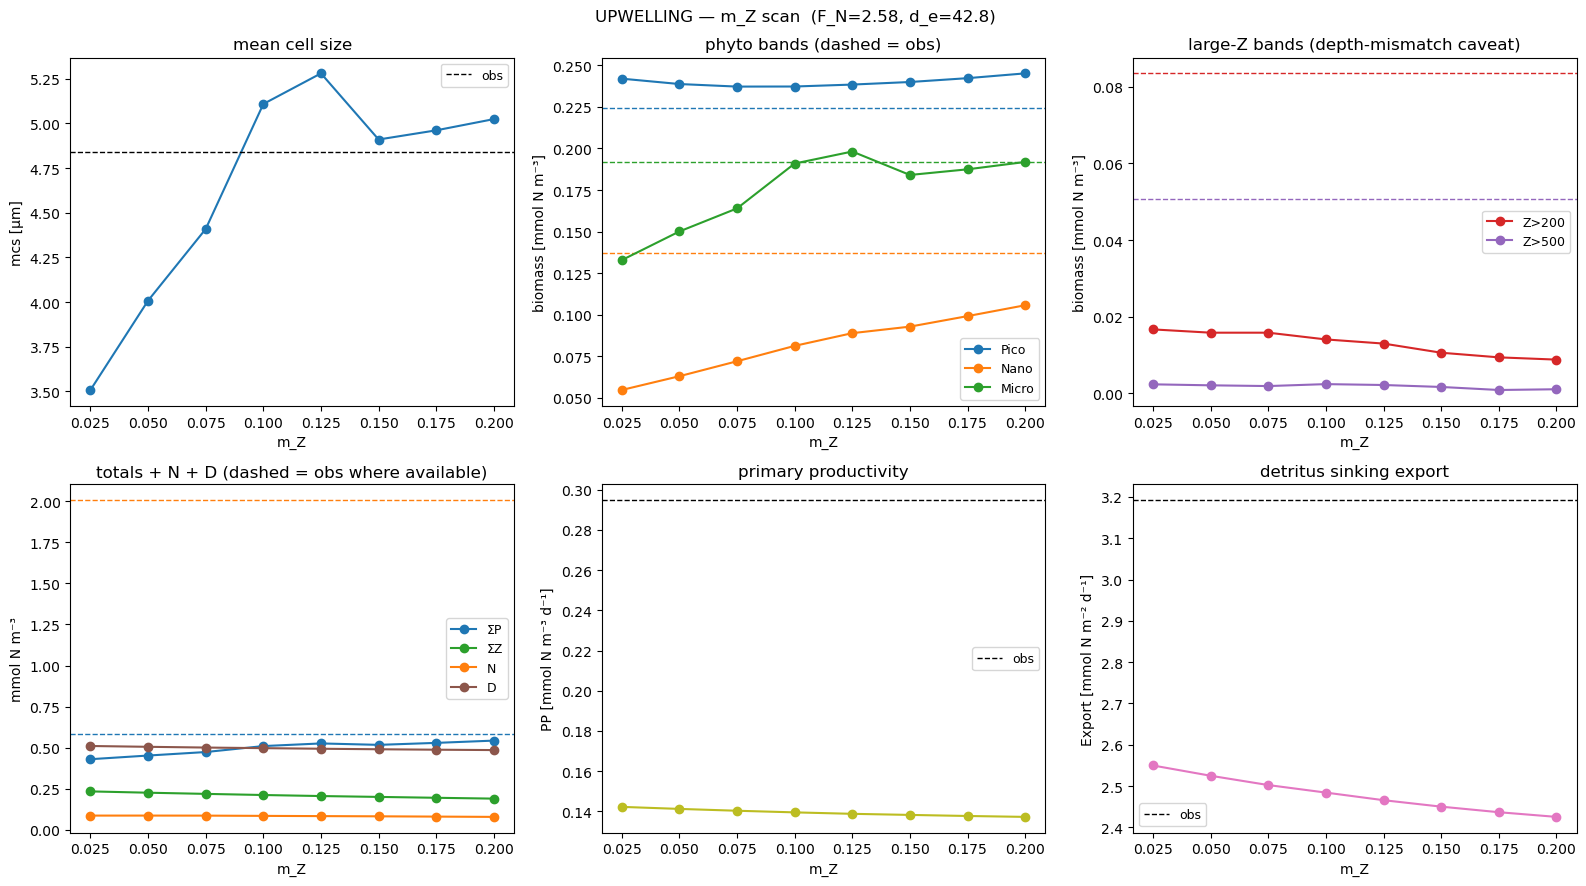

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 8 points using 8 workers...
1D Scan complete. Time taken: 11.19933 seconds.

=== RELAXED — m_Z scan  (F_N=1.45, d_e=52.7) ===
   m_Z    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.025   2.57   0.172   0.058   0.060   0.290  0.0039  0.0000   0.147   0.046   0.287   0.071   1.435
 0.050   2.94   0.171   0.063   0.070   0.304  0.0036  0.0000   0.143   0.046   0.284   0.071   1.422
 0.075   3.03   0.170   0.068   0.072   0.310  0.0033  0.0000   0.139   0.046   0.282   0.070   1.411
 0.100   2.94   0.171   0.074   0.068   0.313  0.0027  0.0000   0.136   0.046   0.280   0.070   1.401
 0.125   2.92   0.173   0.081   0.066   0.319  0.0022  0.0000   0

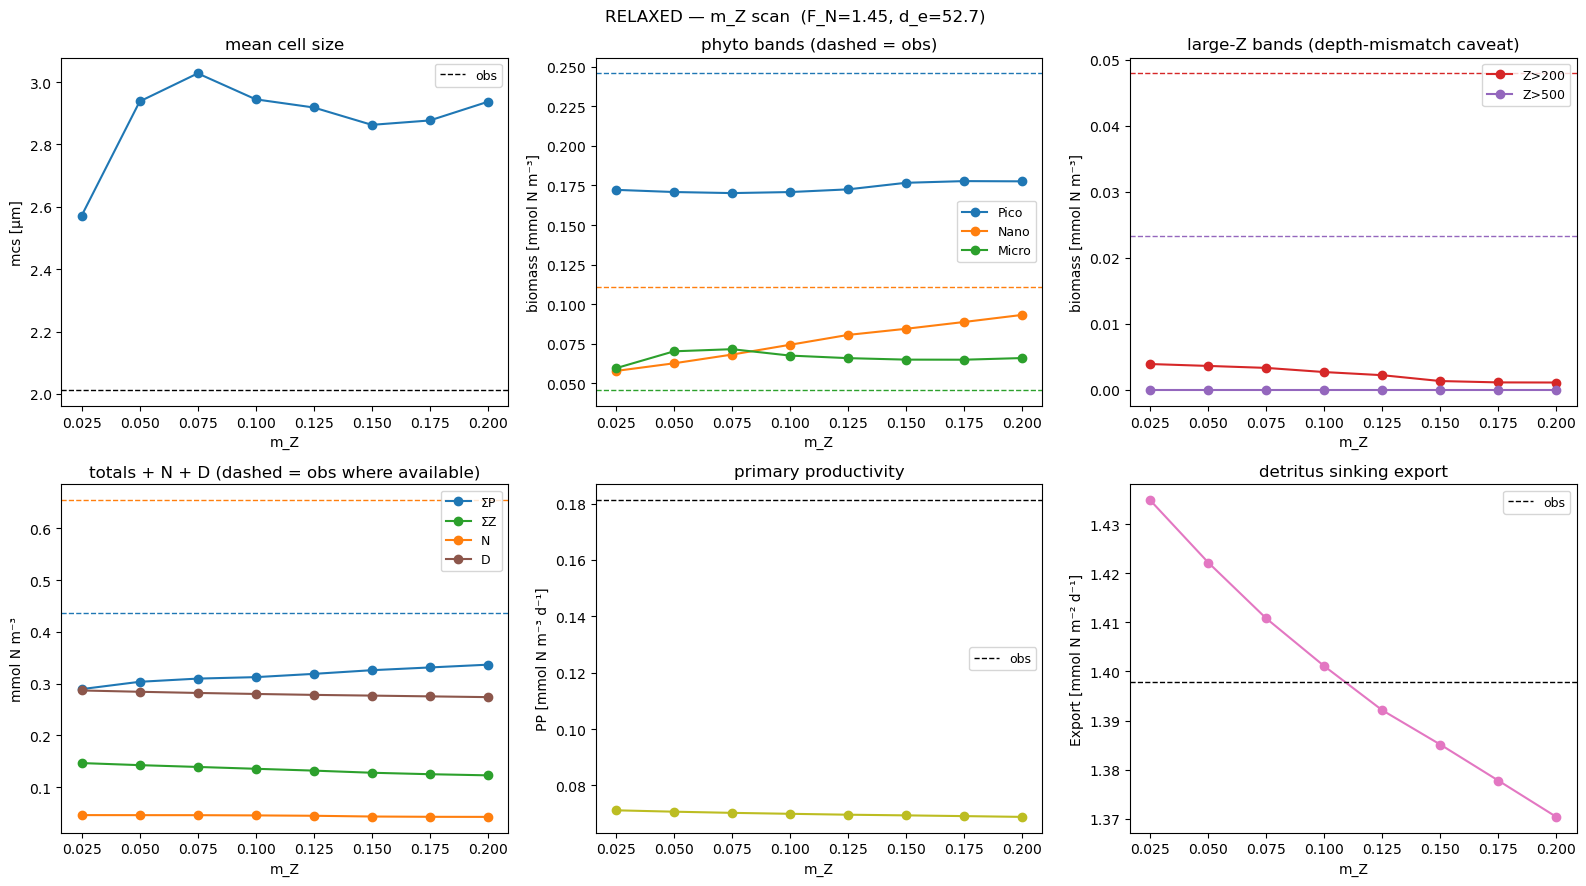

In [10]:
# ── Cell A — m_Z scan (quadratic zoo closure) ────────────────────────────────
# Also initialises obs_refs (used by every scan cell below).
from xso.parscans import run_xso_parscan

PARAM       = 'ZooQuadMortality__rate'
AXIS_VALUES = np.linspace(0.025, 0.20, 8)      # baseline 0.1 included
AXIS_LABEL  = 'm_Z'
SCAN_NAME   = 'm_Z'
TAIL_AVG    = 1000
mP_baseline = np.full(len(phyto_esd), 0.02)

obs_refs = {r: build_obs_refs(targets[r]['monthly_df']) for r in regimes}

param_scans[SCAN_NAME] = {}
for r in regimes:
    overrides = {**targets[r]['forcing'],
                 'PhytoMortality__rate': mP_baseline}
    scan = run_xso_parscan(
        model_file_name='cariaco_npzd_setups',
        model_name='model_npzd',
        model_setup_name='model_setup_npzd_tani',     # full output
        param_name=PARAM,
        param_values=AXIS_VALUES,
        fixed_overrides=overrides,
        postprocess_name='avg_tail',
        postprocess_kwargs={'avg_window': TAIL_AVG},
        processes=8,
    )
    metrics = extract_scan_metrics(scan, PARAM, targets[r]['forcing'])
    param_scans[SCAN_NAME][r] = metrics
    header = (f"{r.upper()} — {AXIS_LABEL} scan  "
              f"(F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
              f"d_e={targets[r]['forcing']['Inflow__de']:.1f})")
    print_scan_table(metrics, obs_refs[r], header, axis_label=AXIS_LABEL)
    plot_scan_panels(metrics, obs_refs[r], header, axis_label=AXIS_LABEL)

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 11 points using 8 workers...
1D Scan complete. Time taken: 17.43384 seconds.

=== UPWELLING — m_Zlin scan  (F_N=2.58, d_e=42.8) ===
m_Zlin    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.000   1.88   0.235   0.011   0.069   0.316  0.0431  0.0037   0.290   0.094   0.480   0.140   2.399
 0.010   2.18   0.237   0.023   0.080   0.341  0.0312  0.0028   0.267   0.091   0.485   0.140   2.426
 0.020   2.83   0.240   0.037   0.107   0.384  0.0225  0.0026   0.250   0.087   0.489   0.140   2.446
 0.030   3.32   0.242   0.052   0.125   0.419  0.0177  0.0022   0.234   0.085   0.492   0.140   2.462
 0.040   4.08   0.237   0.065   0.152   0.454  0.0159  0.00

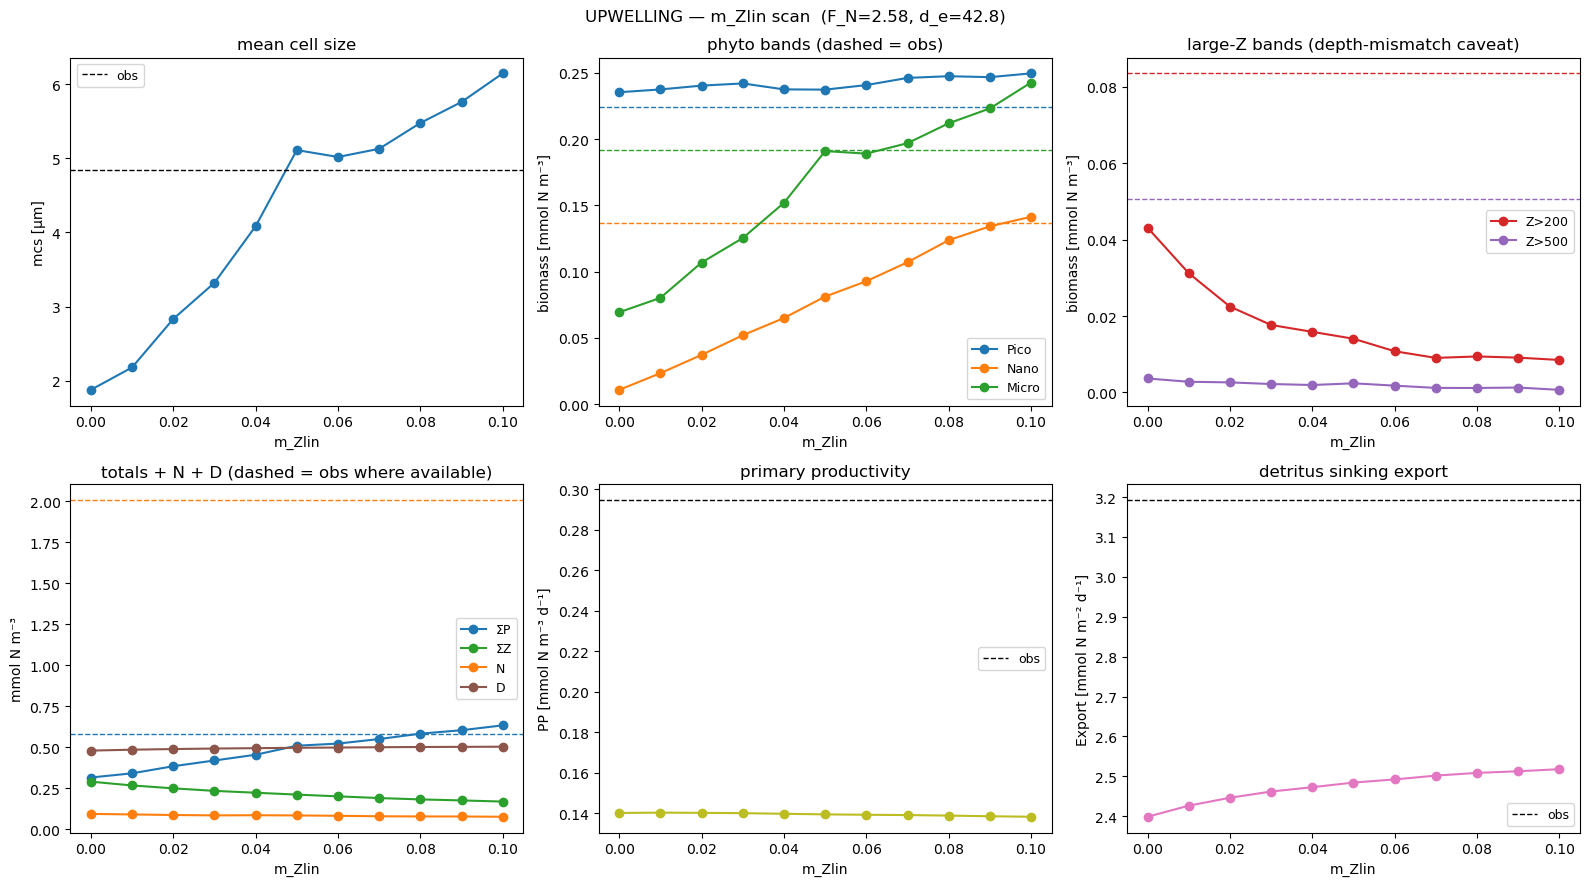

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 11 points using 8 workers...
1D Scan complete. Time taken: 13.7162 seconds.

=== RELAXED — m_Zlin scan  (F_N=1.45, d_e=52.7) ===
m_Zlin    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.000   0.66   0.173   0.004   0.000   0.177  0.0224  0.0000   0.208   0.048   0.267   0.070   1.336
 0.010   1.23   0.171   0.018   0.022   0.210  0.0146  0.0000   0.184   0.048   0.272   0.070   1.361
 0.020   1.59   0.174   0.033   0.031   0.238  0.0074  0.0000   0.168   0.046   0.275   0.070   1.376
 0.030   1.88   0.174   0.045   0.039   0.257  0.0032  0.0000   0.155   0.045   0.277   0.070   1.386
 0.040   2.61   0.171   0.058   0.060   0.289  0.0035  0.0000 

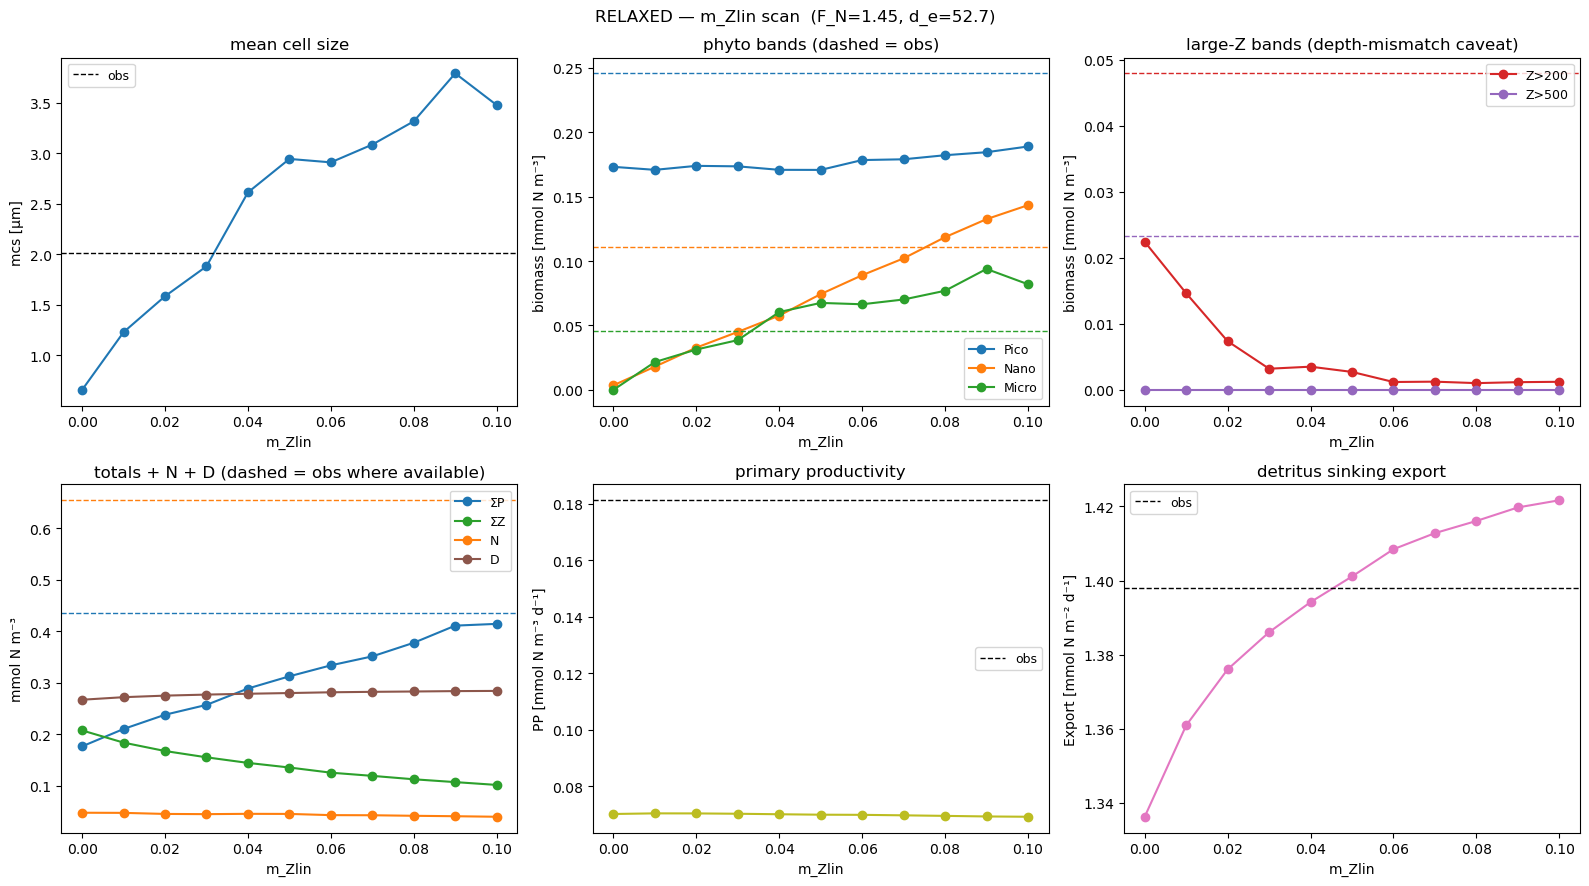

In [11]:
# ── Cell B — m_Zlin scan (linear zoo mortality; fish "double-up" check) ──────
PARAM       = 'ZooLinMortality__rate'
AXIS_VALUES = np.linspace(0.0, 0.10, 11)        # baseline 0.05 included; 0.0 = no linear closure
AXIS_LABEL  = 'm_Zlin'
SCAN_NAME   = 'm_Zlin'
TAIL_AVG    = 1000
mP_baseline = np.full(len(phyto_esd), 0.02)

param_scans[SCAN_NAME] = {}
for r in regimes:
    overrides = {**targets[r]['forcing'],
                 'PhytoMortality__rate': mP_baseline}
    scan = run_xso_parscan(
        model_file_name='cariaco_npzd_setups',
        model_name='model_npzd',
        model_setup_name='model_setup_npzd_tani',
        param_name=PARAM,
        param_values=AXIS_VALUES,
        fixed_overrides=overrides,
        postprocess_name='avg_tail',
        postprocess_kwargs={'avg_window': TAIL_AVG},
        processes=8,
    )
    metrics = extract_scan_metrics(scan, PARAM, targets[r]['forcing'])
    param_scans[SCAN_NAME][r] = metrics
    header = (f"{r.upper()} — {AXIS_LABEL} scan  "
              f"(F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
              f"d_e={targets[r]['forcing']['Inflow__de']:.1f})")
    print_scan_table(metrics, obs_refs[r], header, axis_label=AXIS_LABEL)
    plot_scan_panels(metrics, obs_refs[r], header, axis_label=AXIS_LABEL)


=== UPWELLING — m_P scan  (F_N=2.58, d_e=42.8) ===
   m_P    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.005   9.10   0.244   0.098   0.355   0.698  0.0291  0.0120   0.224   0.080   0.494   0.140   2.471
 0.010   8.97   0.238   0.093   0.342   0.673  0.0196  0.0073   0.219   0.082   0.495   0.140   2.476
 0.020   5.11   0.237   0.081   0.191   0.509  0.0141  0.0024   0.211   0.084   0.497   0.140   2.484
 0.040   1.48   0.240   0.067   0.028   0.335  0.0037  0.0000   0.204   0.086   0.498   0.139   2.490
 0.060   1.02   0.236   0.062   0.000   0.298  0.0000  0.0000   0.200   0.085   0.499   0.139   2.494
 0.080   0.86   0.229   0.035   0.000   0.264  0.0000  0.0000   0.197   0.088   0.499   0.138   2.495
 0.100   0.74   0.223   0.017   0.000   0.240  0.0000  0.0000   0.196   0.092   0.499   0.138   2.497
   obs   4.84   0.224   0.137   0.192   0.583  0.0835  0.0506       -   2.006       -   0.295   3.192


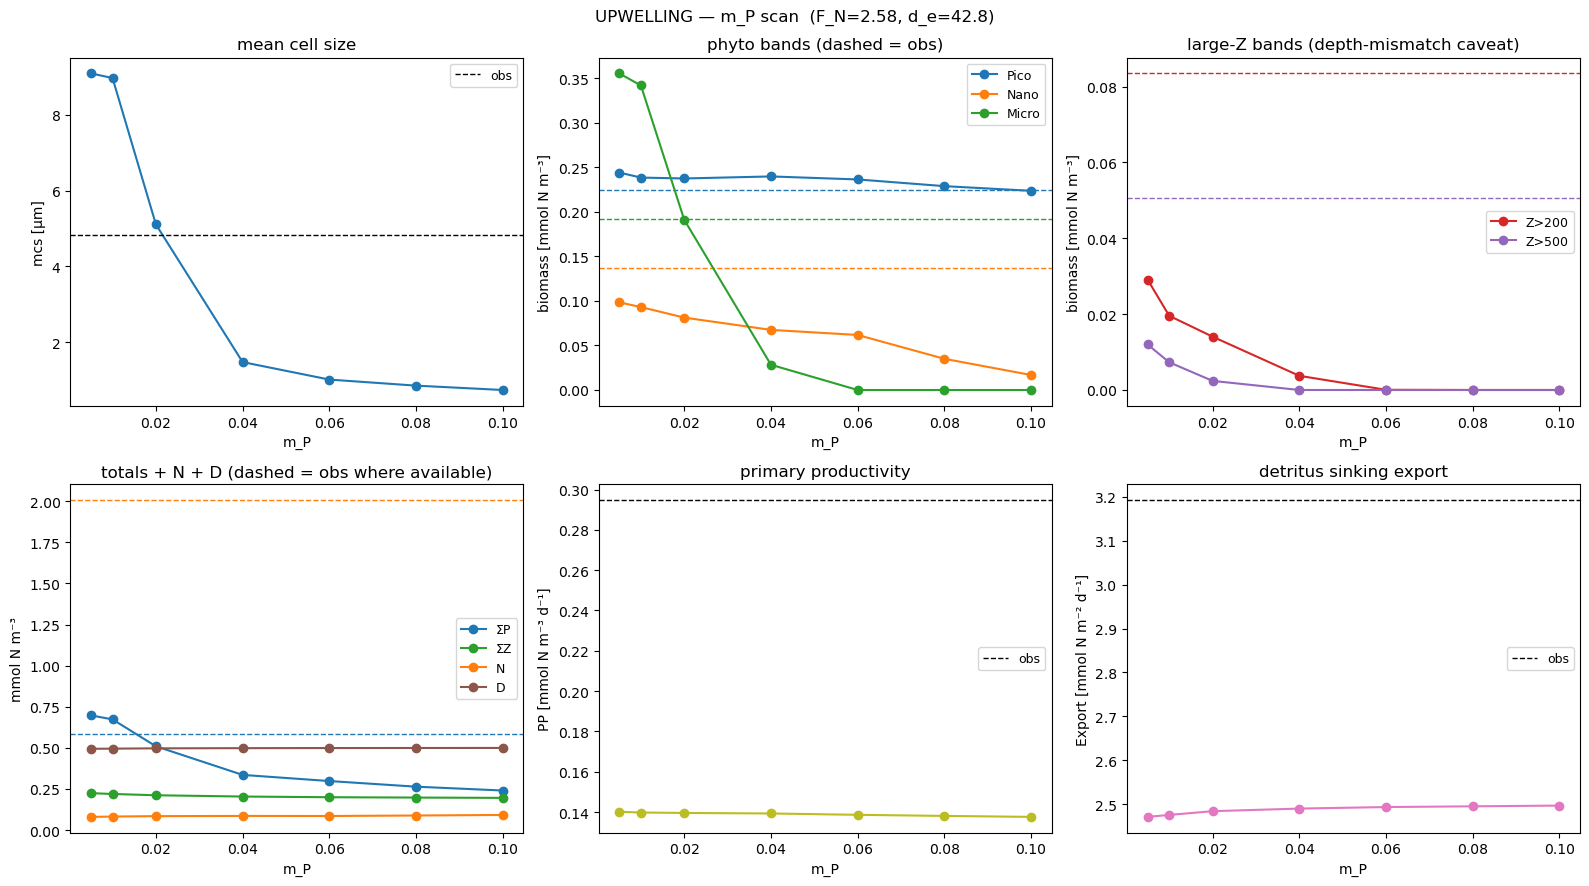


=== RELAXED — m_P scan  (F_N=1.45, d_e=52.7) ===
   m_P    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.005  10.01   0.183   0.092   0.297   0.572  0.0120  0.0037   0.142   0.041   0.279   0.070   1.396
 0.010   7.26   0.178   0.085   0.207   0.470  0.0075  0.0014   0.139   0.042   0.280   0.070   1.400
 0.020   2.94   0.171   0.074   0.068   0.313  0.0027  0.0000   0.136   0.046   0.280   0.070   1.401
 0.040   1.17   0.167   0.062   0.000   0.229  0.0000  0.0000   0.130   0.047   0.281   0.070   1.405
 0.060   0.90   0.162   0.030   0.000   0.191  0.0000  0.0000   0.127   0.049   0.281   0.069   1.407
 0.080   0.71   0.156   0.009   0.000   0.165  0.0000  0.0000   0.126   0.052   0.282   0.069   1.408
 0.100   0.64   0.152   0.001   0.000   0.152  0.0000  0.0000   0.123   0.054   0.282   0.069   1.410
   obs   2.01   0.246   0.111   0.046   0.436  0.0479  0.0233       -   0.654       -   0.181   1.398


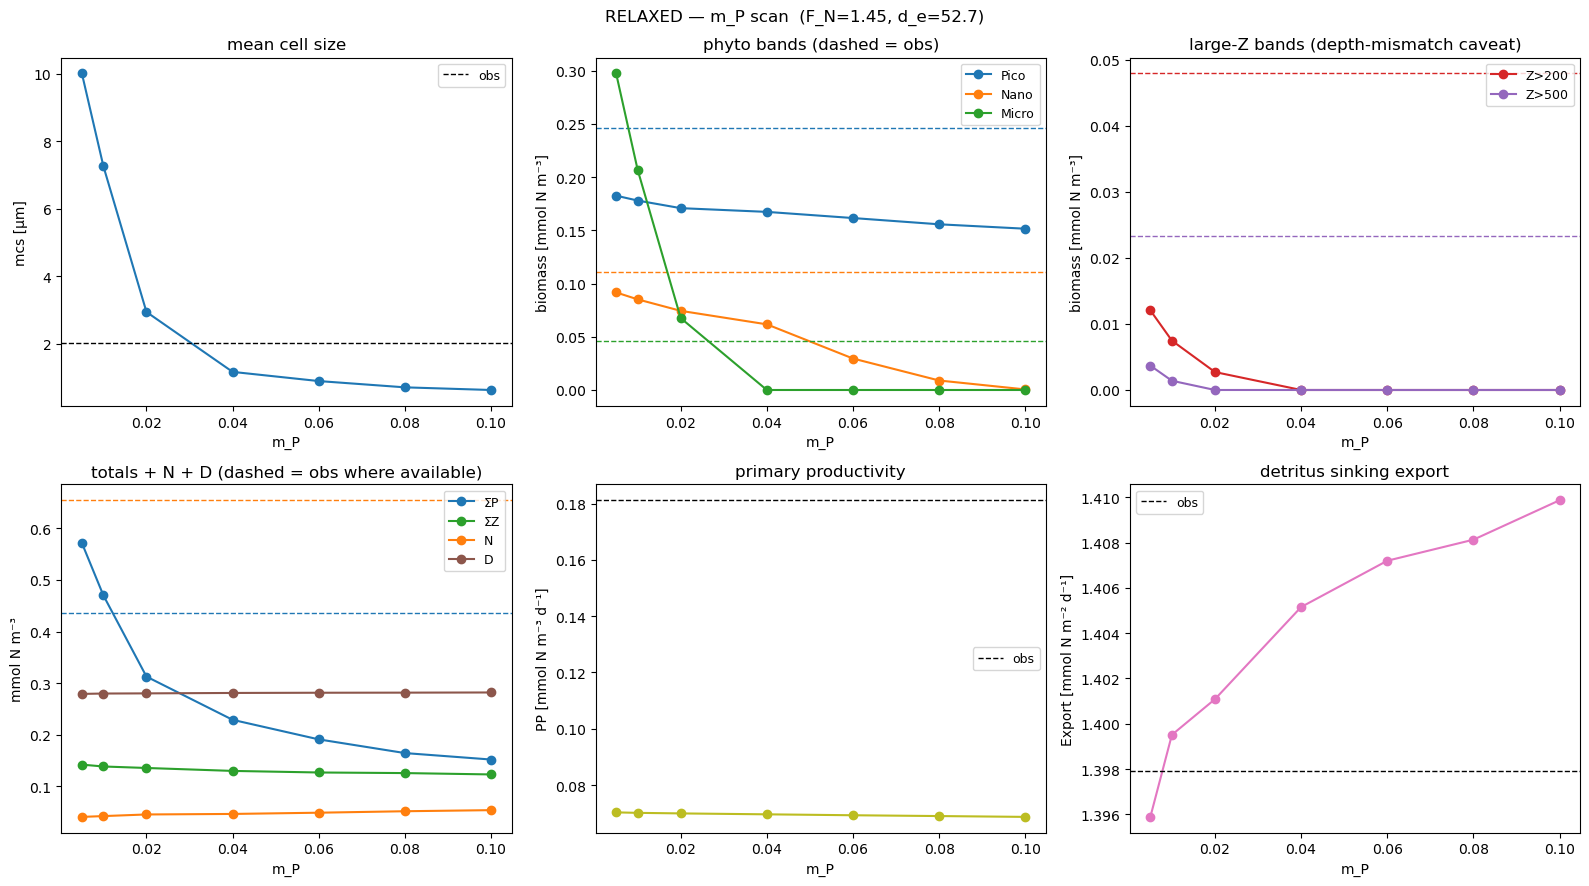

In [12]:
# ── Cell C — m_P scan (uniform phyto mortality; array slot, Python loop) ─────
# Array slots can't be the parscan axis (handoff gotcha), so we run single
# points per m_P value and build the same metrics dict the helper expects.
AXIS_VALUES = np.array([0.005, 0.01, 0.02, 0.04, 0.06, 0.08, 0.10])  # baseline 0.02
AXIS_LABEL  = 'm_P'
SCAN_NAME   = 'm_P'
TAIL_AVG    = 1000
n_P         = len(phyto_esd)

param_scans[SCAN_NAME] = {}
for r in regimes:
    d_e = float(targets[r]['forcing']['Inflow__de'])
    arrs = {k: [] for k in ['mcs', 'P_pico', 'P_nano', 'P_micro', 'sumP',
                            'Z_gt200', 'Z_gt500', 'sumZ', 'N', 'D', 'PP', 'Export']}
    for v in AXIS_VALUES:
        overrides = {**targets[r]['forcing'],
                     'PhytoMortality__rate': np.full(n_P, float(v))}
        out = pu.run_single_point(cns.model_npzd, cns.model_setup_npzd_tani,
                                  scan_params={}, fixed_overrides=overrides)
        T = out.isel(time=slice(-TAIL_AVG, None))
        P = T['Phytoplankton__biomass'].mean('time').values
        Z = T['Zooplankton__biomass'].mean('time').values
        bins = P @ W_PHYTO.T
        frac = bins / max(bins.sum(), 1e-30)
        arrs['mcs'].append(float(10.0 ** (frac @ np.log10(GEOMEANS))))
        arrs['P_pico'].append(float(bins[0]))
        arrs['P_nano'].append(float(bins[1]))
        arrs['P_micro'].append(float(bins[2]))
        arrs['sumP'].append(float(P.sum()))
        arrs['Z_gt200'].append(float(Z[M_Z200].sum()))
        arrs['Z_gt500'].append(float(Z[M_Z500].sum()))
        arrs['sumZ'].append(float(Z.sum()))
        arrs['N'].append(float(T['Nutrient__value'].mean('time')))
        arrs['D'].append(float(T['Detritus__value'].mean('time')))
        arrs['PP'].append(float(T['Growth__uptake_value'].mean('time').sum()))
        arrs['Export'].append(float(T['DetritusSink__sinking_value'].mean('time')) * d_e)
    metrics = {k: np.array(v) for k, v in arrs.items()}
    metrics['axis'] = AXIS_VALUES
    param_scans[SCAN_NAME][r] = metrics
    header = (f"{r.upper()} — {AXIS_LABEL} scan  "
              f"(F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
              f"d_e={targets[r]['forcing']['Inflow__de']:.1f})")
    print_scan_table(metrics, obs_refs[r], header, axis_label=AXIS_LABEL)
    plot_scan_panels(metrics, obs_refs[r], header, axis_label=AXIS_LABEL)

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 6 points using 8 workers...
1D Scan complete. Time taken: 9.80414 seconds.

=== UPWELLING — GGE scan  (F_N=2.58, d_e=42.8) ===
   GGE    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.150   4.65   0.276   0.153   0.194   0.624  0.0067  0.0000   0.150   0.071   0.506   0.142   2.530
 0.200   4.91   0.253   0.112   0.193   0.558  0.0105  0.0007   0.181   0.078   0.502   0.141   2.509
 0.250   5.11   0.237   0.081   0.191   0.509  0.0141  0.0024   0.211   0.084   0.497   0.140   2.484
 0.300   3.79   0.235   0.057   0.140   0.431  0.0170  0.0019   0.240   0.086   0.491   0.138   2.456
 0.350   3.22   0.228   0.043   0.115   0.386  0.0273  0.0021   

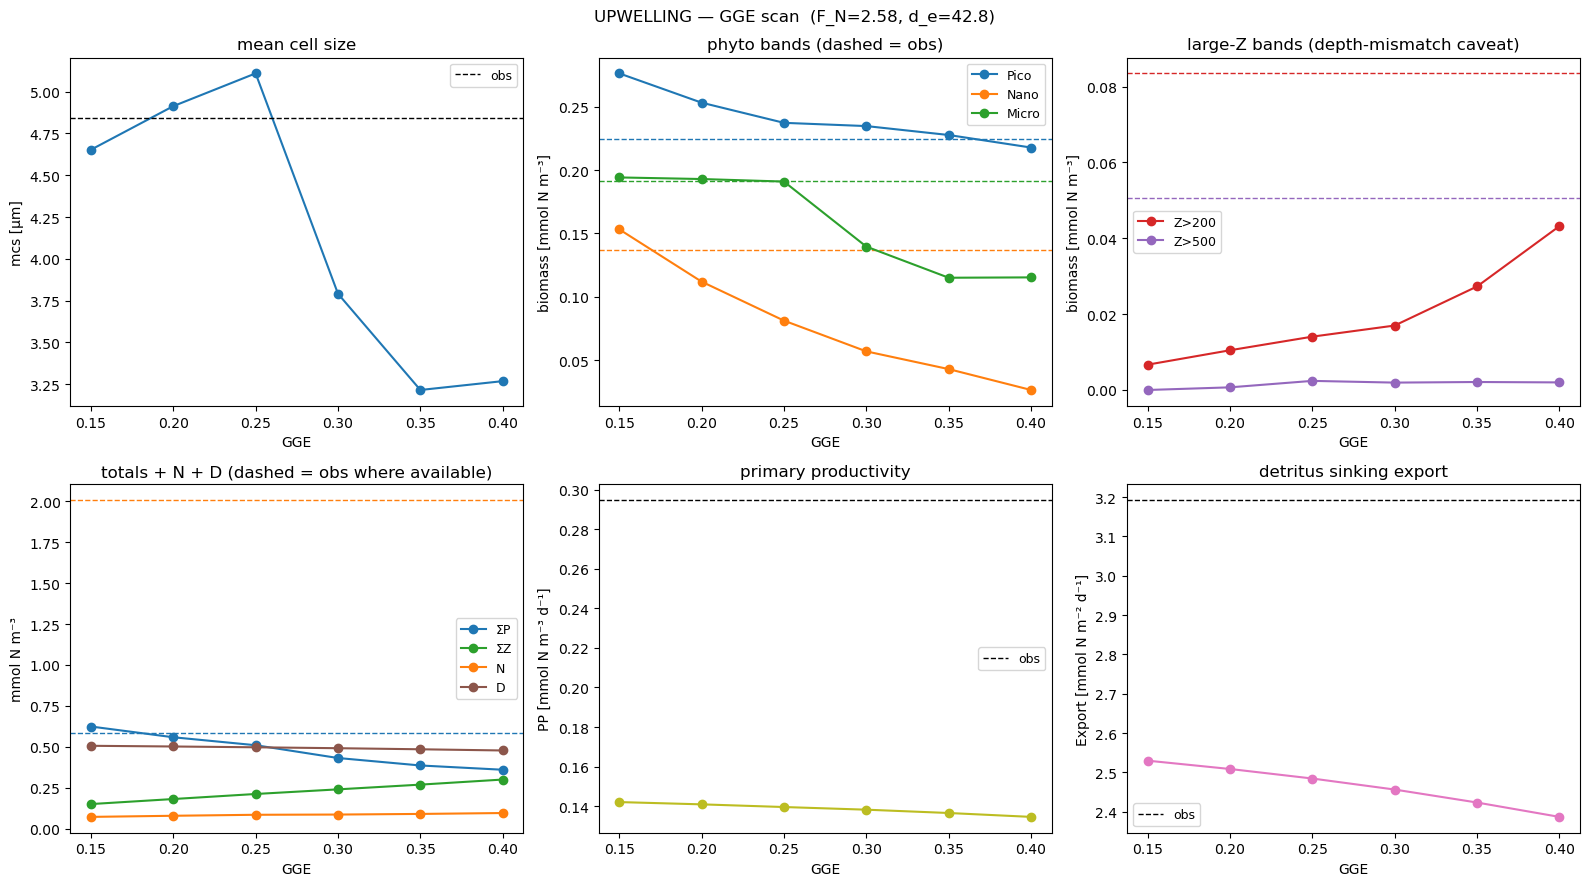

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 6 points using 8 workers...
1D Scan complete. Time taken: 8.73484 seconds.

=== RELAXED — GGE scan  (F_N=1.45, d_e=52.7) ===
   GGE    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.150   2.86   0.204   0.137   0.065   0.406  0.0011  0.0000   0.093   0.038   0.285   0.071   1.427
 0.200   2.96   0.184   0.100   0.068   0.353  0.0011  0.0000   0.115   0.042   0.283   0.071   1.415
 0.250   2.94   0.171   0.074   0.068   0.313  0.0027  0.0000   0.136   0.046   0.280   0.070   1.401
 0.300   2.21   0.169   0.055   0.046   0.270  0.0034  0.0000   0.154   0.046   0.277   0.069   1.387
 0.350   2.11   0.166   0.043   0.045   0.255  0.0077  0.0000   0.

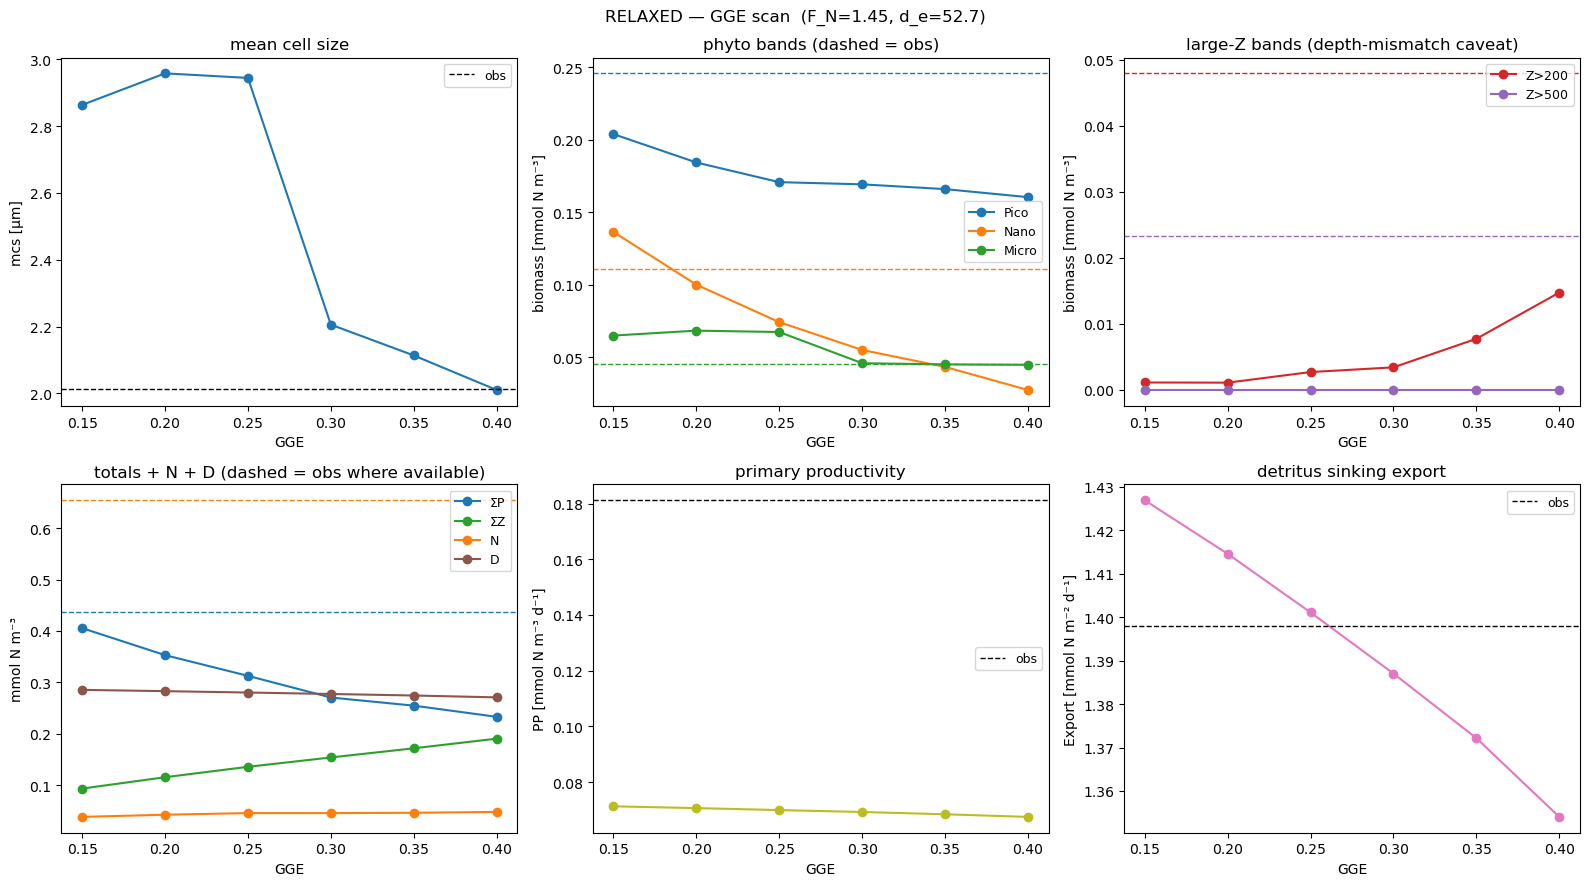

In [13]:
# ── Cell D — GGE scan (community grazing efficiency) ─────────────────────────
PARAM       = 'GrazingRouter__gge'
AXIS_VALUES = np.array([0.15, 0.20, 0.25, 0.30, 0.35, 0.40])  # baseline 0.25
AXIS_LABEL  = 'GGE'
SCAN_NAME   = 'GGE'
TAIL_AVG    = 1000
mP_baseline = np.full(len(phyto_esd), 0.02)

param_scans[SCAN_NAME] = {}
for r in regimes:
    overrides = {**targets[r]['forcing'],
                 'PhytoMortality__rate': mP_baseline}
    scan = run_xso_parscan(
        model_file_name='cariaco_npzd_setups',
        model_name='model_npzd',
        model_setup_name='model_setup_npzd_tani',
        param_name=PARAM,
        param_values=AXIS_VALUES,
        fixed_overrides=overrides,
        postprocess_name='avg_tail',
        postprocess_kwargs={'avg_window': TAIL_AVG},
        processes=8,
    )
    metrics = extract_scan_metrics(scan, PARAM, targets[r]['forcing'])
    param_scans[SCAN_NAME][r] = metrics
    header = (f"{r.upper()} — {AXIS_LABEL} scan  "
              f"(F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
              f"d_e={targets[r]['forcing']['Inflow__de']:.1f})")
    print_scan_table(metrics, obs_refs[r], header, axis_label=AXIS_LABEL)
    plot_scan_panels(metrics, obs_refs[r], header, axis_label=AXIS_LABEL)

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 5 points using 8 workers...
1D Scan complete. Time taken: 9.29563 seconds.

=== UPWELLING — k_remin scan  (F_N=2.58, d_e=42.8) ===
k_remin    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.025   3.63   0.205   0.086   0.109   0.400  0.0056  0.0000   0.165   0.059   0.504   0.092   2.521
 0.050   4.06   0.214   0.082   0.132   0.429  0.0056  0.0000   0.183   0.068   0.501   0.108   2.507
 0.100   5.11   0.237   0.081   0.191   0.509  0.0141  0.0024   0.211   0.084   0.497   0.140   2.484
 0.200   6.42   0.272   0.080   0.277   0.629  0.0255  0.0075   0.261   0.118   0.486   0.201   2.432
 0.400   6.47   0.328   0.087   0.337   0.752  0.0547  0.01

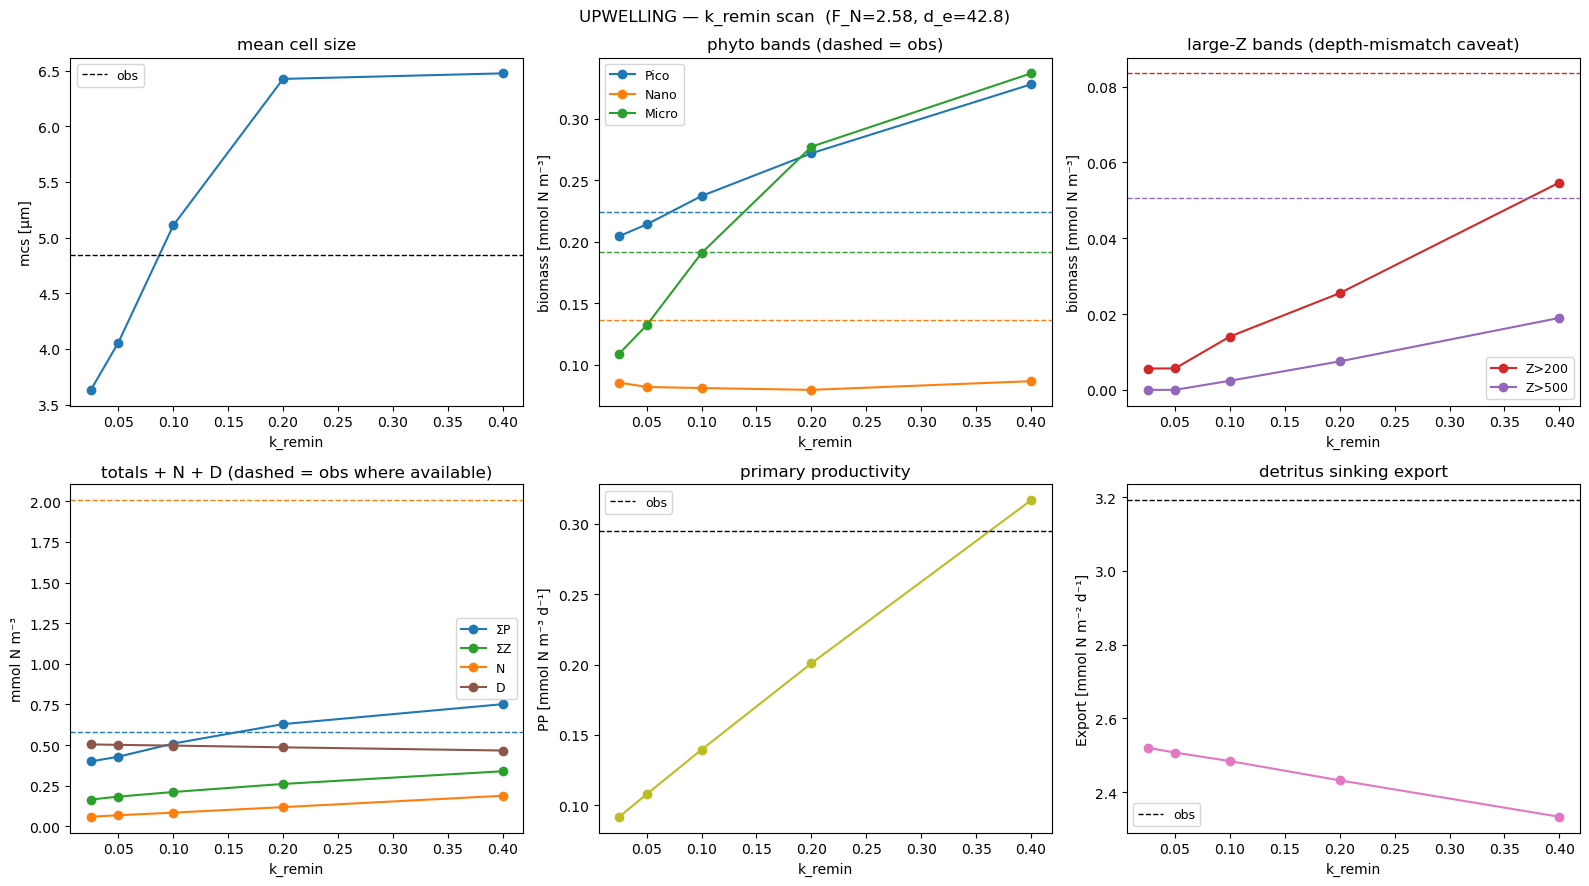

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 5 points using 8 workers...
1D Scan complete. Time taken: 8.15151 seconds.

=== RELAXED — k_remin scan  (F_N=1.45, d_e=52.7) ===
k_remin    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.025   1.68   0.150   0.089   0.008   0.247  0.0000  0.0000   0.099   0.031   0.285   0.043   1.424
 0.050   2.00   0.157   0.083   0.025   0.265  0.0008  0.0000   0.113   0.036   0.283   0.052   1.416
 0.100   2.94   0.171   0.074   0.068   0.313  0.0027  0.0000   0.136   0.046   0.280   0.070   1.401
 0.200   3.84   0.196   0.067   0.115   0.378  0.0067  0.0000   0.173   0.063   0.274   0.104   1.371
 0.400   5.17   0.235   0.064   0.193   0.491  0.0188  0.0048

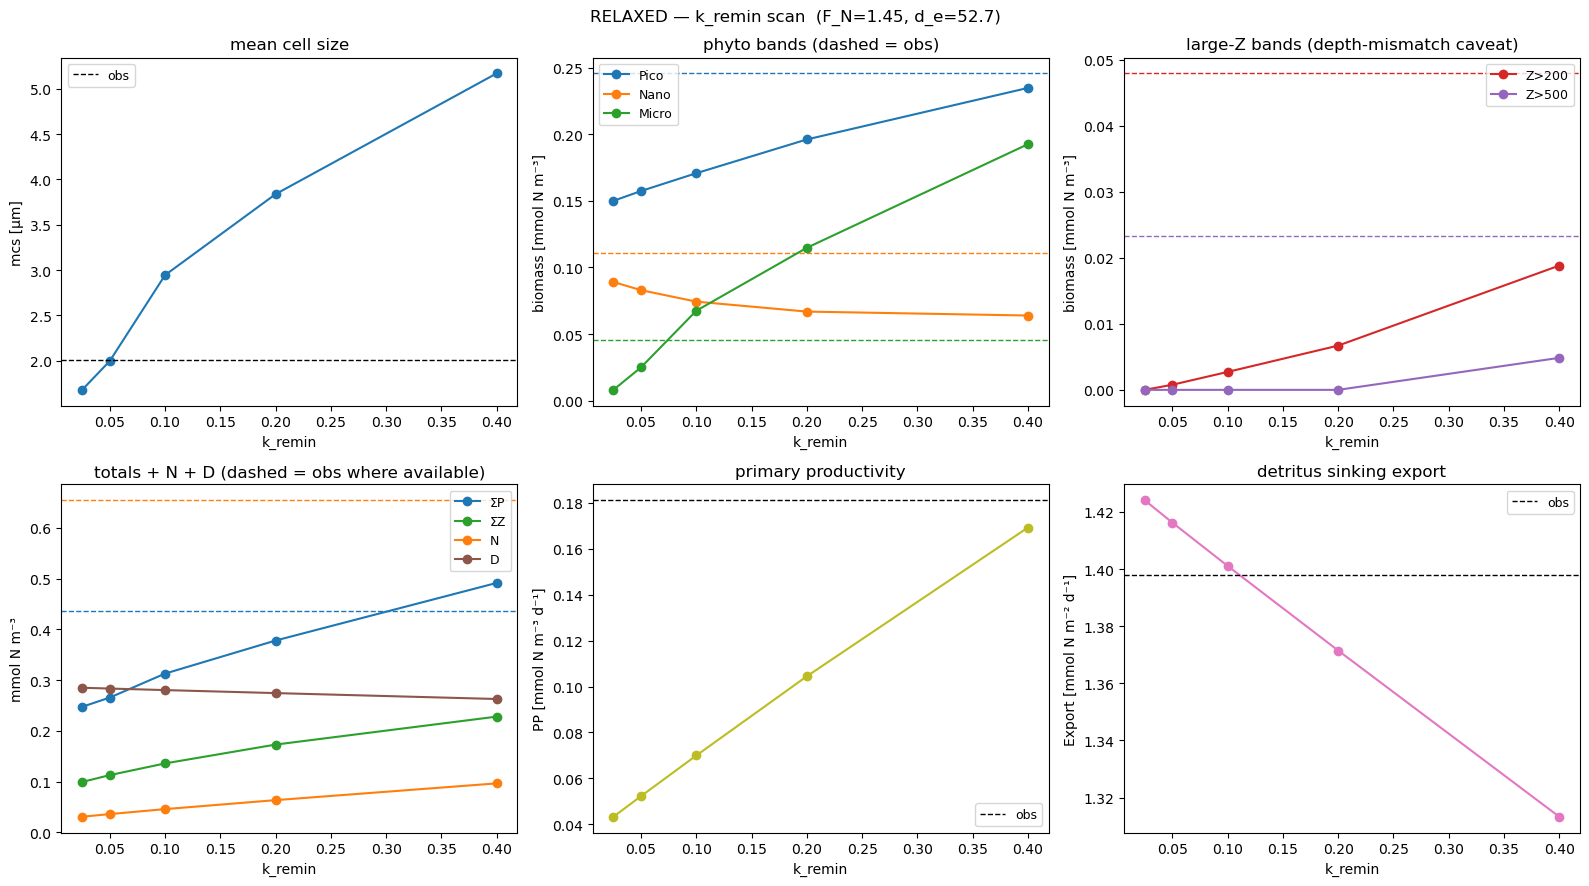

In [14]:
# ── Cell E — k_remin scan (detritus remineralisation rate) ───────────────────
PARAM       = 'DetritusRemin__k_remin'
AXIS_VALUES = np.array([0.025, 0.05, 0.1, 0.2, 0.4])     # baseline 0.1
AXIS_LABEL  = 'k_remin'
SCAN_NAME   = 'k_remin'
TAIL_AVG    = 1000
mP_baseline = np.full(len(phyto_esd), 0.02)

param_scans[SCAN_NAME] = {}
for r in regimes:
    overrides = {**targets[r]['forcing'],
                 'PhytoMortality__rate': mP_baseline}
    scan = run_xso_parscan(
        model_file_name='cariaco_npzd_setups',
        model_name='model_npzd',
        model_setup_name='model_setup_npzd_tani',
        param_name=PARAM,
        param_values=AXIS_VALUES,
        fixed_overrides=overrides,
        postprocess_name='avg_tail',
        postprocess_kwargs={'avg_window': TAIL_AVG},
        processes=8,
    )
    metrics = extract_scan_metrics(scan, PARAM, targets[r]['forcing'])
    param_scans[SCAN_NAME][r] = metrics
    header = (f"{r.upper()} — {AXIS_LABEL} scan  "
              f"(F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
              f"d_e={targets[r]['forcing']['Inflow__de']:.1f})")
    print_scan_table(metrics, obs_refs[r], header, axis_label=AXIS_LABEL)
    plot_scan_panels(metrics, obs_refs[r], header, axis_label=AXIS_LABEL)

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 5 points using 8 workers...
1D Scan complete. Time taken: 9.2271 seconds.

=== UPWELLING — w_sink scan  (F_N=2.58, d_e=42.8) ===
w_sink    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 1.000   6.15   0.350   0.093   0.341   0.785  0.0653  0.0276   0.372   0.226   2.283   0.371   2.283
 2.500   6.39   0.271   0.080   0.275   0.626  0.0256  0.0076   0.261   0.119   0.973   0.201   2.432
 5.000   5.11   0.237   0.081   0.191   0.509  0.0141  0.0024   0.211   0.084   0.497   0.140   2.484
10.000   4.06   0.214   0.082   0.132   0.428  0.0056  0.0000   0.183   0.068   0.251   0.108   2.507
20.000   3.64   0.205   0.086   0.109   0.400  0.0056  0.0000 

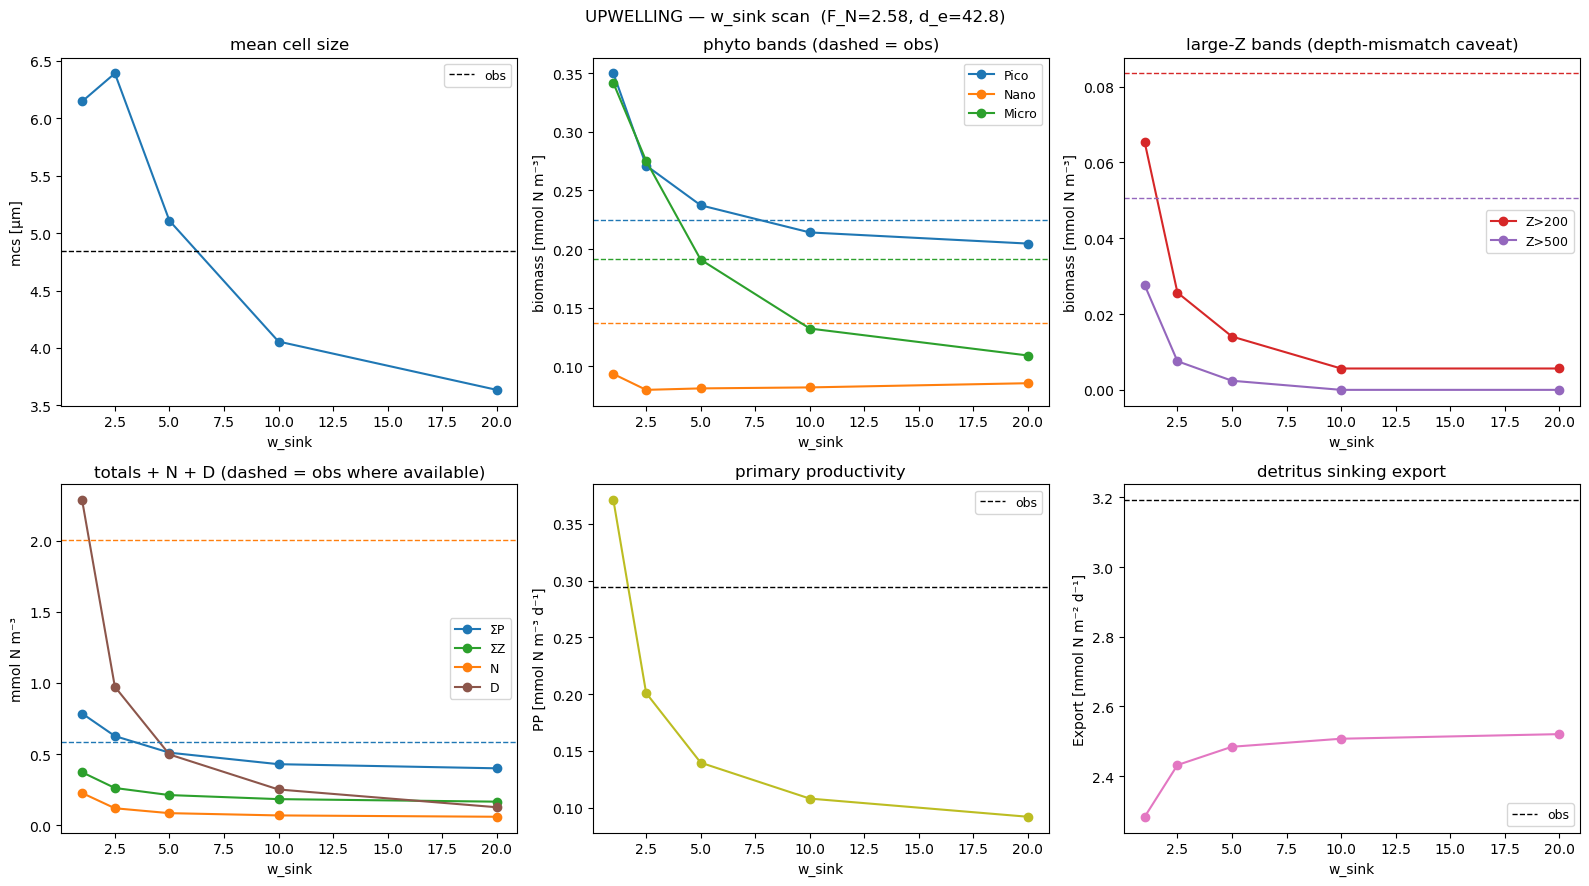

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 5 points using 8 workers...
1D Scan complete. Time taken: 8.78526 seconds.

=== RELAXED — w_sink scan  (F_N=1.45, d_e=52.7) ===
w_sink    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 1.000   5.98   0.251   0.065   0.238   0.554  0.0284  0.0065   0.250   0.113   1.286   0.200   1.286
 2.500   3.86   0.196   0.067   0.116   0.379  0.0066  0.0000   0.173   0.063   0.549   0.104   1.371
 5.000   2.94   0.171   0.074   0.068   0.313  0.0027  0.0000   0.136   0.046   0.280   0.070   1.401
10.000   2.00   0.158   0.083   0.025   0.266  0.0008  0.0000   0.113   0.036   0.142   0.052   1.416
20.000   1.68   0.150   0.089   0.008   0.247  0.0000  0.0000  

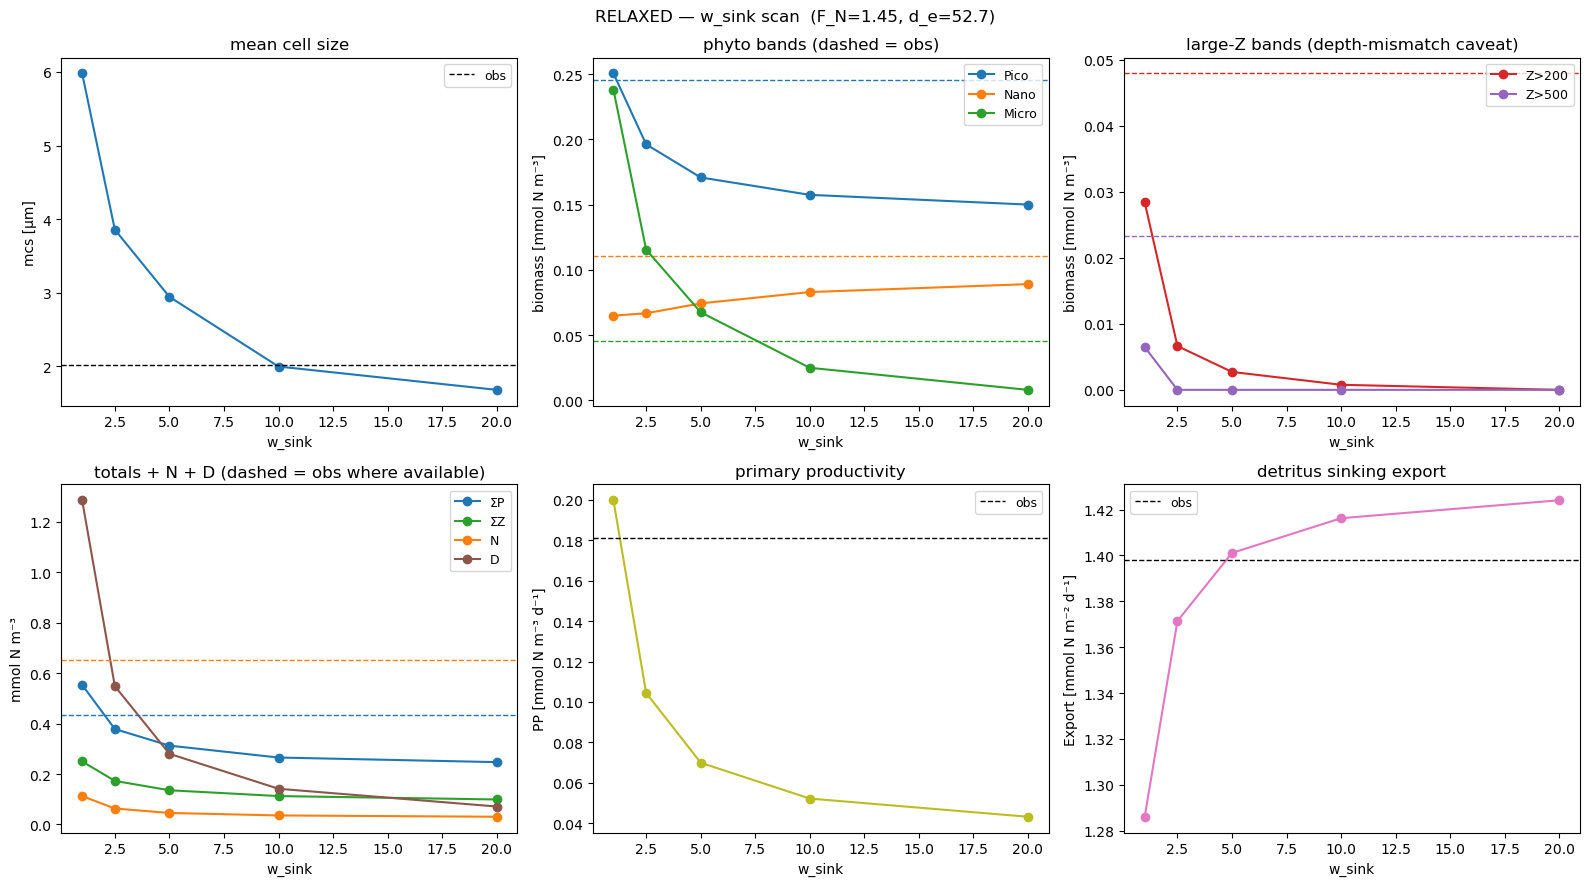

In [15]:
# ── Cell F — w_sink scan (detritus sinking speed) ────────────────────────────
PARAM       = 'DetritusSink__w_sink'
AXIS_VALUES = np.array([1.0, 2.5, 5.0, 10.0, 20.0])      # baseline 5.0
AXIS_LABEL  = 'w_sink'
SCAN_NAME   = 'w_sink'
TAIL_AVG    = 1000
mP_baseline = np.full(len(phyto_esd), 0.02)

param_scans[SCAN_NAME] = {}
for r in regimes:
    overrides = {**targets[r]['forcing'],
                 'PhytoMortality__rate': mP_baseline}
    scan = run_xso_parscan(
        model_file_name='cariaco_npzd_setups',
        model_name='model_npzd',
        model_setup_name='model_setup_npzd_tani',
        param_name=PARAM,
        param_values=AXIS_VALUES,
        fixed_overrides=overrides,
        postprocess_name='avg_tail',
        postprocess_kwargs={'avg_window': TAIL_AVG},
        processes=8,
    )
    metrics = extract_scan_metrics(scan, PARAM, targets[r]['forcing'])
    param_scans[SCAN_NAME][r] = metrics
    header = (f"{r.upper()} — {AXIS_LABEL} scan  "
              f"(F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
              f"d_e={targets[r]['forcing']['Inflow__de']:.1f})")
    print_scan_table(metrics, obs_refs[r], header, axis_label=AXIS_LABEL)
    plot_scan_panels(metrics, obs_refs[r], header, axis_label=AXIS_LABEL)

In [16]:
# ── Cell G — closure-form variant: bulk vs per-class quadratic ───────────────
# Not a continuous scan — single point per regime under each variant at defaults.
SCAN_NAME   = 'closure_form'
TAIL_AVG    = 1000
mP_baseline = np.full(len(phyto_esd), 0.02)

param_scans[SCAN_NAME] = {}
for r in regimes:
    d_e = float(targets[r]['forcing']['Inflow__de'])
    rr  = {}
    for form_name, model, setup in [
        ('bulk',      cns.model_npzd,           cns.model_setup_npzd_tani),
        ('per_class', cns.model_npzd_perclassZ, cns.model_setup_npzd_tani_perclassZ),
    ]:
        overrides = {**targets[r]['forcing'],
                     'PhytoMortality__rate': mP_baseline}
        out = pu.run_single_point(model, setup, scan_params={},
                                  fixed_overrides=overrides)
        T = out.isel(time=slice(-TAIL_AVG, None))
        P = T['Phytoplankton__biomass'].mean('time').values
        Z = T['Zooplankton__biomass'].mean('time').values
        bins = P @ W_PHYTO.T
        frac = bins / max(bins.sum(), 1e-30)
        rr[form_name] = dict(
            mcs    = float(10.0 ** (frac @ np.log10(GEOMEANS))),
            P_pico = float(bins[0]), P_nano = float(bins[1]), P_micro = float(bins[2]),
            sumP   = float(P.sum()),
            Z_gt200= float(Z[M_Z200].sum()),
            Z_gt500= float(Z[M_Z500].sum()),
            sumZ   = float(Z.sum()),
            N      = float(T['Nutrient__value'].mean('time')),
            D      = float(T['Detritus__value'].mean('time')),
            PP     = float(T['Growth__uptake_value'].mean('time').sum()),
            Export = float(T['DetritusSink__sinking_value'].mean('time')) * d_e,
        )
    param_scans[SCAN_NAME][r] = rr

    # side-by-side table (no plot — only 2 points per regime)
    o  = obs_refs[r]
    f3 = lambda v: f"{v:9.3f}" if np.isfinite(v) else f"{'-':>9}"
    f4 = lambda v: f"{v:9.4f}" if np.isfinite(v) else f"{'-':>9}"
    fm = lambda v: f"{v:9.2f}" if np.isfinite(v) else f"{'-':>9}"
    print(f"\n=== {r.upper()} — closure-form  "
          f"(F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
          f"d_e={targets[r]['forcing']['Inflow__de']:.1f}) ===")
    print(f"{'var':>8} {'bulk':>9} {'per_class':>9} {'obs':>9}")
    rows = [('mcs', fm, 'mcs'), ('P_pico', f3, 'Pico'), ('P_nano', f3, 'Nano'),
            ('P_micro', f3, 'Micro'), ('sumP', f3, 'ΣP'),
            ('Z_gt200', f4, 'Z>200'), ('Z_gt500', f4, 'Z>500'),
            ('sumZ', f3, 'ΣZ'), ('N', f3, 'N'), ('D', f3, 'D'),
            ('PP', f3, 'PP'), ('Export', f3, 'Exp')]
    for key, fmt, lbl in rows:
        print(f"{lbl:>8} {fmt(rr['bulk'][key])} {fmt(rr['per_class'][key])} "
              f"{fmt(o.get(key, np.nan))}")


=== UPWELLING — closure-form  (F_N=2.58, d_e=42.8) ===
     var      bulk per_class       obs
     mcs      5.11      3.14      4.84
    Pico     0.237     0.242     0.224
    Nano     0.081     0.047     0.137
   Micro     0.191     0.119     0.192
      ΣP     0.509     0.408     0.583
   Z>200    0.0141    0.0200    0.0835
   Z>500    0.0024    0.0028    0.0506
      ΣZ     0.211     0.241         -
       N     0.084     0.088     2.006
       D     0.497     0.514         -
      PP     0.140     0.143     0.295
     Exp     2.484     2.571     3.192

=== RELAXED — closure-form  (F_N=1.45, d_e=52.7) ===
     var      bulk per_class       obs
     mcs      2.94      2.34      2.01
    Pico     0.171     0.174     0.246
    Nano     0.074     0.055     0.111
   Micro     0.068     0.053     0.046
      ΣP     0.313     0.281     0.436
   Z>200    0.0027    0.0034    0.0479
   Z>500    0.0000    0.0000    0.0233
      ΣZ     0.136     0.150         -
       N     0.046     0.046    


=== UPWELLING — K_sZ scan  (F_N=2.58, d_e=42.8) ===
  K_sZ    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.100   4.75   0.147   0.028   0.112   0.286  0.0294  0.0105   0.162   0.199   0.505   0.143   2.523
 0.150   5.83   0.183   0.044   0.169   0.395  0.0210  0.0053   0.185   0.129   0.501   0.141   2.505
 0.200   4.82   0.218   0.064   0.166   0.448  0.0129  0.0018   0.203   0.096   0.498   0.140   2.491
 0.230   5.11   0.237   0.081   0.191   0.509  0.0141  0.0024   0.211   0.084   0.497   0.140   2.484
 0.300   4.80   0.280   0.122   0.208   0.610  0.0077  0.0000   0.228   0.066   0.493   0.138   2.467
 0.350   3.28   0.318   0.149   0.145   0.612  0.0050  0.0000   0.236   0.057   0.492   0.138   2.459
 0.400   3.05   0.349   0.181   0.139   0.669  0.0026  0.0000   0.244   0.050   0.490   0.137   2.452
 0.450   3.11   0.376   0.225   0.146   0.747  0.0031  0.0000   0.251   0.045   0.489   0.136   2.444
   obs   4.84   0.224   0.137

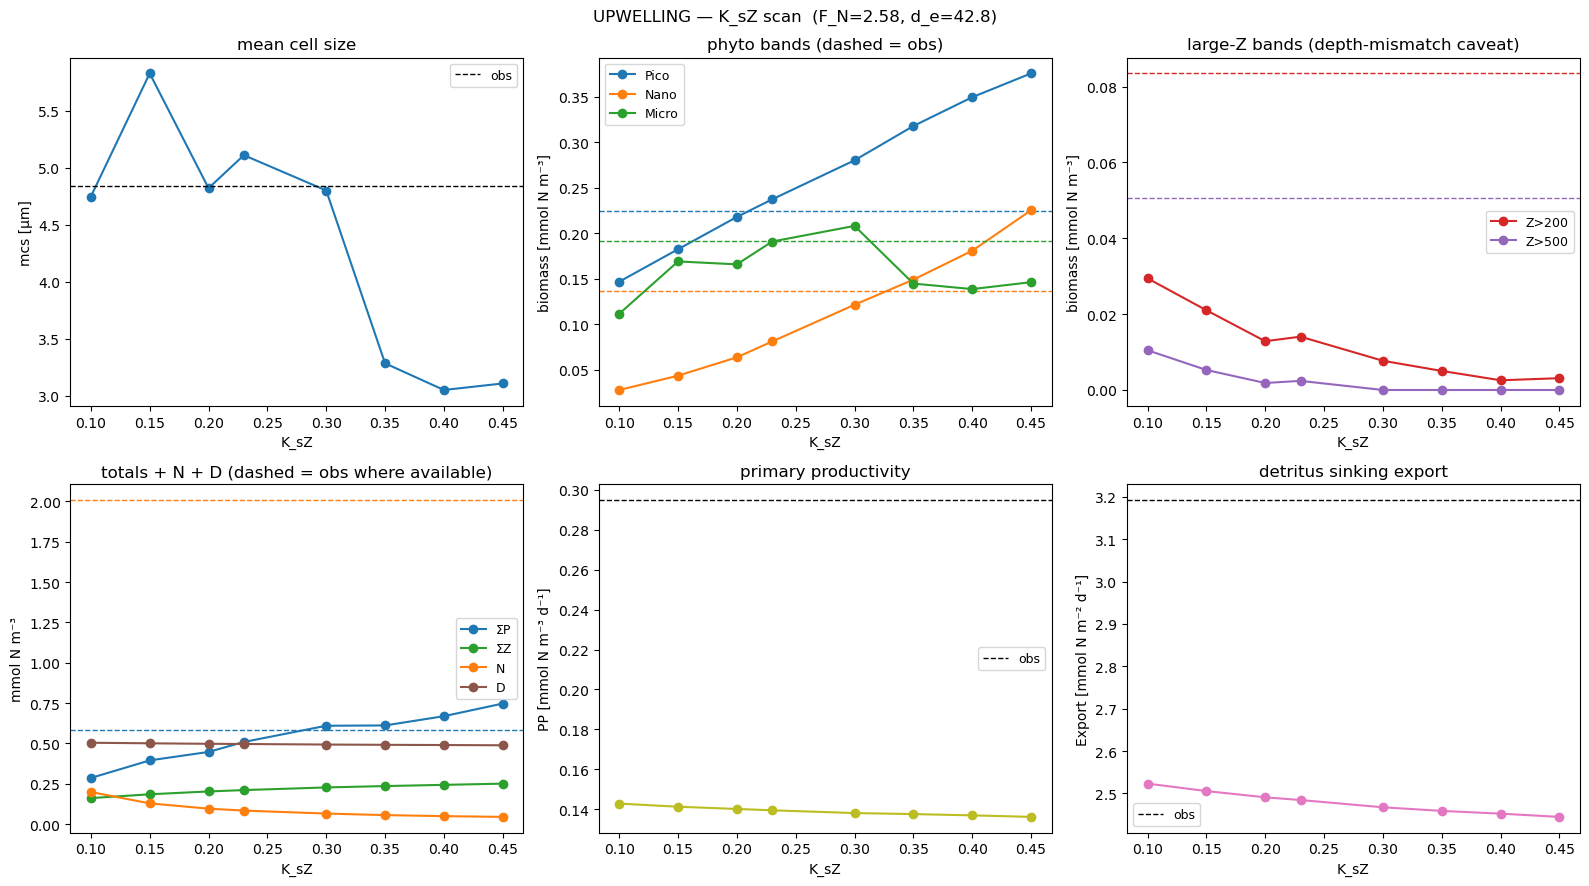


=== RELAXED — K_sZ scan  (F_N=1.45, d_e=52.7) ===
  K_sZ    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.100   3.99   0.103   0.021   0.066   0.190  0.0096  0.0017   0.103   0.093   0.284   0.072   1.422
 0.150   3.79   0.131   0.039   0.077   0.247  0.0055  0.0002   0.119   0.065   0.283   0.071   1.413
 0.200   3.13   0.156   0.061   0.069   0.286  0.0042  0.0000   0.130   0.051   0.281   0.070   1.405
 0.230   2.94   0.171   0.074   0.068   0.313  0.0027  0.0000   0.136   0.046   0.280   0.070   1.401
 0.300   2.14   0.209   0.112   0.040   0.361  0.0008  0.0000   0.145   0.036   0.279   0.069   1.394
 0.350   1.81   0.235   0.145   0.019   0.398  0.0000  0.0000   0.150   0.031   0.278   0.069   1.391
 0.400   1.75   0.258   0.186   0.007   0.452  0.0000  0.0000   0.153   0.028   0.278   0.069   1.388
 0.450   1.61   0.279   0.192   0.000   0.472  0.0000  0.0000   0.159   0.026   0.277   0.068   1.383
   obs   2.01   0.246   0.111  

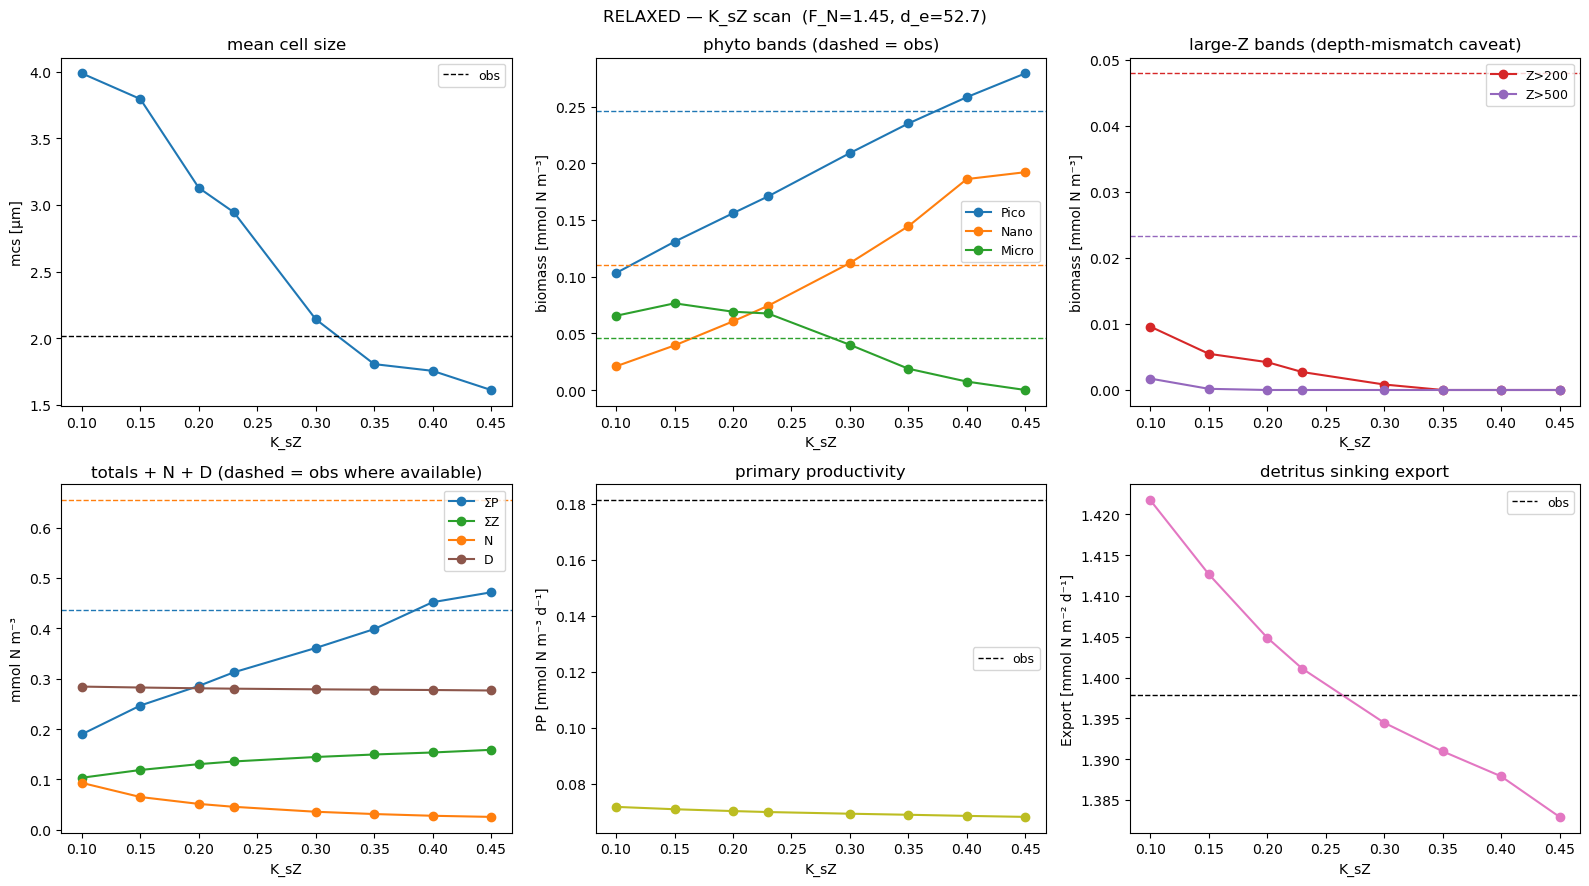

In [18]:
# ── Cell H — K_sZ scan (grazing half-sat; array slot, Python loop) ───────────
# K_sZ is part of the Dutkiewicz single-source grazing package (locked at 0.23
# under feedback_single_source_allometry); scanned here as a what-if, not a
# baseline candidate. Survey: K_sZ ≤ 0.05 returned NaN-dominated output;
# Type-III window per Ward / Dutkiewicz / Rohr is 0.15–0.45.
AXIS_VALUES = np.array([0.10, 0.15, 0.20, 0.23, 0.30, 0.35, 0.40, 0.45])  # baseline 0.23
AXIS_LABEL  = 'K_sZ'
SCAN_NAME   = 'K_sZ'
TAIL_AVG    = 1000
mP_baseline = np.full(len(phyto_esd), 0.02)
n_Z         = len(zoo_esd)

param_scans[SCAN_NAME] = {}
for r in regimes:
    d_e = float(targets[r]['forcing']['Inflow__de'])
    arrs = {k: [] for k in ['mcs', 'P_pico', 'P_nano', 'P_micro', 'sumP',
                            'Z_gt200', 'Z_gt500', 'sumZ', 'N', 'D', 'PP', 'Export']}
    for v in AXIS_VALUES:
        overrides = {**targets[r]['forcing'],
                     'PhytoMortality__rate': mP_baseline,
                     'Grazing__KsZ':         np.full(n_Z, float(v))}
        out = pu.run_single_point(cns.model_npzd, cns.model_setup_npzd_tani,
                                  scan_params={}, fixed_overrides=overrides)
        T = out.isel(time=slice(-TAIL_AVG, None))
        P = T['Phytoplankton__biomass'].mean('time').values
        Z = T['Zooplankton__biomass'].mean('time').values
        bins = P @ W_PHYTO.T
        frac = bins / max(bins.sum(), 1e-30)
        arrs['mcs'].append(float(10.0 ** (frac @ np.log10(GEOMEANS))))
        arrs['P_pico'].append(float(bins[0]))
        arrs['P_nano'].append(float(bins[1]))
        arrs['P_micro'].append(float(bins[2]))
        arrs['sumP'].append(float(P.sum()))
        arrs['Z_gt200'].append(float(Z[M_Z200].sum()))
        arrs['Z_gt500'].append(float(Z[M_Z500].sum()))
        arrs['sumZ'].append(float(Z.sum()))
        arrs['N'].append(float(T['Nutrient__value'].mean('time')))
        arrs['D'].append(float(T['Detritus__value'].mean('time')))
        arrs['PP'].append(float(T['Growth__uptake_value'].mean('time').sum()))
        arrs['Export'].append(float(T['DetritusSink__sinking_value'].mean('time')) * d_e)
    metrics = {k: np.array(v) for k, v in arrs.items()}
    metrics['axis'] = AXIS_VALUES
    param_scans[SCAN_NAME][r] = metrics
    header = (f"{r.upper()} — {AXIS_LABEL} scan  "
              f"(F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
              f"d_e={targets[r]['forcing']['Inflow__de']:.1f})")
    print_scan_table(metrics, obs_refs[r], header, axis_label=AXIS_LABEL)
    plot_scan_panels(metrics, obs_refs[r], header, axis_label=AXIS_LABEL)


=== UPWELLING — sigma scan  (F_N=2.58, d_e=42.8) ===
 sigma    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.100   4.46   0.300   0.142   0.203   0.646  0.0094  0.0000   0.241   0.063   0.491   0.137   2.455
 0.150   5.11   0.237   0.081   0.191   0.509  0.0141  0.0024   0.211   0.084   0.497   0.140   2.484
 0.200   4.08   0.211   0.052   0.136   0.398  0.0165  0.0022   0.188   0.099   0.501   0.141   2.503
 0.250   4.45   0.190   0.035   0.135   0.361  0.0180  0.0045   0.170   0.112   0.503   0.142   2.516
 0.300   4.28   0.171   0.024   0.118   0.314  0.0200  0.0054   0.158   0.128   0.505   0.143   2.526
 0.350   3.69   0.157   0.023   0.094   0.274  0.0157  0.0059   0.152   0.148   0.506   0.143   2.529
   obs   4.84   0.224   0.137   0.192   0.583  0.0835  0.0506       -   2.006       -   0.295   3.192


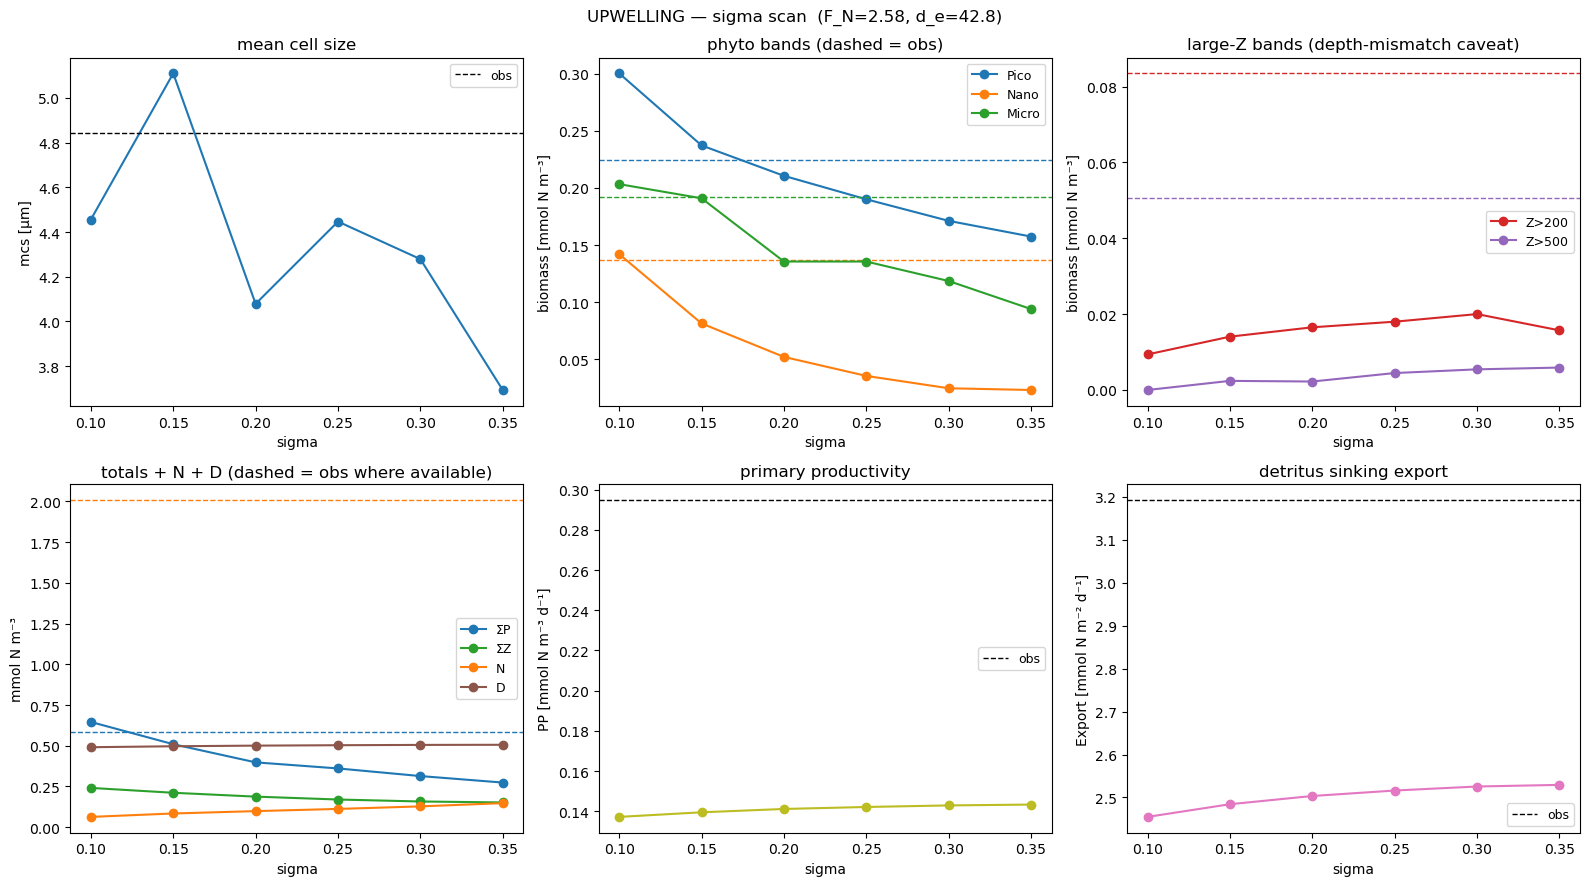


=== RELAXED — sigma scan  (F_N=1.45, d_e=52.7) ===
 sigma    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.100   2.55   0.223   0.136   0.059   0.418  0.0008  0.0000   0.152   0.034   0.278   0.069   1.390
 0.150   2.94   0.171   0.074   0.068   0.313  0.0027  0.0000   0.136   0.046   0.280   0.070   1.401
 0.200   2.66   0.149   0.051   0.054   0.255  0.0032  0.0000   0.121   0.052   0.282   0.071   1.411
 0.250   2.76   0.136   0.033   0.055   0.225  0.0036  0.0000   0.109   0.057   0.284   0.071   1.418
 0.300   3.34   0.120   0.025   0.063   0.208  0.0050  0.0000   0.103   0.064   0.285   0.072   1.423
 0.350   2.45   0.115   0.020   0.042   0.178  0.0045  0.0000   0.096   0.069   0.285   0.072   1.425
   obs   2.01   0.246   0.111   0.046   0.436  0.0479  0.0233       -   0.654       -   0.181   1.398


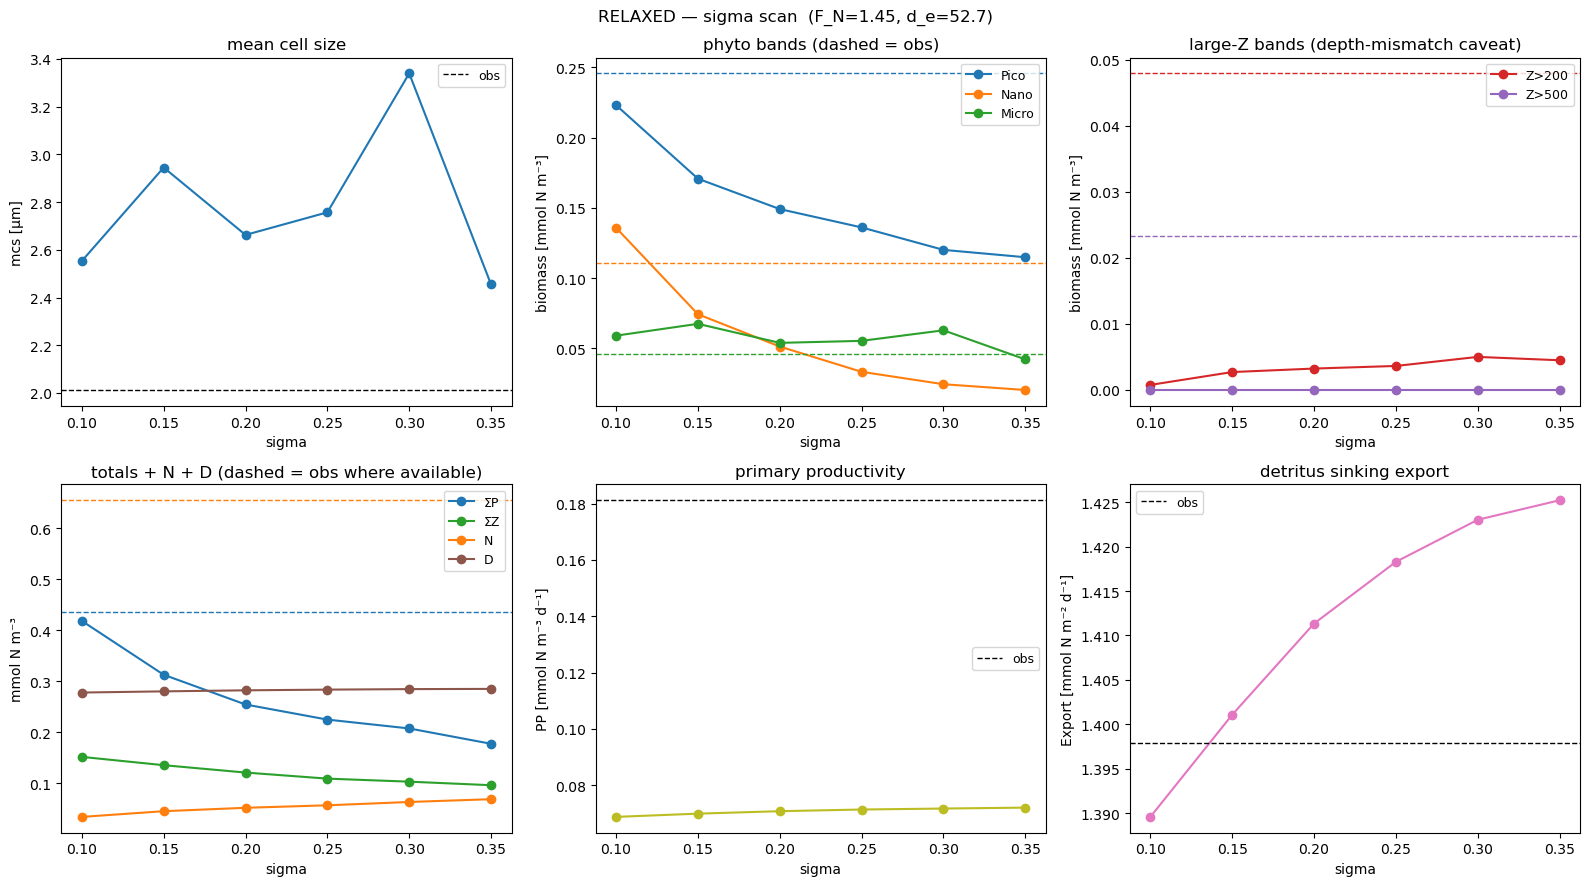

In [19]:
# ── Cell I — grazing kernel width σ scan (rebuilt phiPZ per σ; Python loop) ──
# σ is part of the Dutkiewicz single-source grazing package (locked at 0.15);
# scanned as a what-if, not a baseline candidate. Same convention='mattern'
# normalisation as the baseline kernel build.
from cariaco_npzd_setups import compute_grazing_kernel, THETA_OPT

AXIS_VALUES = np.array([0.10, 0.15, 0.20, 0.25, 0.30, 0.35])    # baseline 0.15
AXIS_LABEL  = 'sigma'
SCAN_NAME   = 'kernel_sigma'
TAIL_AVG    = 1000
mP_baseline = np.full(len(phyto_esd), 0.02)

param_scans[SCAN_NAME] = {}
for r in regimes:
    d_e = float(targets[r]['forcing']['Inflow__de'])
    arrs = {k: [] for k in ['mcs', 'P_pico', 'P_nano', 'P_micro', 'sumP',
                            'Z_gt200', 'Z_gt500', 'sumZ', 'N', 'D', 'PP', 'Export']}
    for v in AXIS_VALUES:
        phiPZ_v = compute_grazing_kernel(
            phyto_esd, zoo_esd, mode='omni',
            theta_opt=THETA_OPT, sigma_log=float(v),
            convention='mattern')
        overrides = {**targets[r]['forcing'],
                     'PhytoMortality__rate': mP_baseline,
                     'Grazing__phiPZ':       phiPZ_v}
        out = pu.run_single_point(cns.model_npzd, cns.model_setup_npzd_tani,
                                  scan_params={}, fixed_overrides=overrides)
        T = out.isel(time=slice(-TAIL_AVG, None))
        P = T['Phytoplankton__biomass'].mean('time').values
        Z = T['Zooplankton__biomass'].mean('time').values
        bins = P @ W_PHYTO.T
        frac = bins / max(bins.sum(), 1e-30)
        arrs['mcs'].append(float(10.0 ** (frac @ np.log10(GEOMEANS))))
        arrs['P_pico'].append(float(bins[0]))
        arrs['P_nano'].append(float(bins[1]))
        arrs['P_micro'].append(float(bins[2]))
        arrs['sumP'].append(float(P.sum()))
        arrs['Z_gt200'].append(float(Z[M_Z200].sum()))
        arrs['Z_gt500'].append(float(Z[M_Z500].sum()))
        arrs['sumZ'].append(float(Z.sum()))
        arrs['N'].append(float(T['Nutrient__value'].mean('time')))
        arrs['D'].append(float(T['Detritus__value'].mean('time')))
        arrs['PP'].append(float(T['Growth__uptake_value'].mean('time').sum()))
        arrs['Export'].append(float(T['DetritusSink__sinking_value'].mean('time')) * d_e)
    metrics = {k: np.array(v) for k, v in arrs.items()}
    metrics['axis'] = AXIS_VALUES
    param_scans[SCAN_NAME][r] = metrics
    header = (f"{r.upper()} — {AXIS_LABEL} scan  "
              f"(F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
              f"d_e={targets[r]['forcing']['Inflow__de']:.1f})")
    print_scan_table(metrics, obs_refs[r], header, axis_label=AXIS_LABEL)
    plot_scan_panels(metrics, obs_refs[r], header, axis_label=AXIS_LABEL)

In [21]:
# ── Dump every stored scan in the standard table format ─────────────────────
for scan_name, by_regime in param_scans.items():
    if scan_name == 'closure_form':
        continue  # has its own side-by-side format; copy its output separately
    for r in regimes:
        metrics = by_regime[r]
        header  = (f"{scan_name} — {r.upper()}  "
                   f"(F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
                   f"d_e={targets[r]['forcing']['Inflow__de']:.1f})")
        # axis_label = same as the scan name
        print_scan_table(metrics, obs_refs[r], header, axis_label=scan_name)


=== m_Z — UPWELLING  (F_N=2.58, d_e=42.8) ===
   m_Z    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.025   3.51   0.242   0.055   0.133   0.430  0.0167  0.0023   0.233   0.086   0.510   0.142   2.550
 0.050   4.01   0.239   0.063   0.150   0.452  0.0158  0.0021   0.225   0.086   0.505   0.141   2.525
 0.075   4.41   0.237   0.072   0.164   0.473  0.0158  0.0019   0.218   0.086   0.500   0.140   2.503
 0.100   5.11   0.237   0.081   0.191   0.509  0.0141  0.0024   0.211   0.084   0.497   0.140   2.484
 0.125   5.28   0.238   0.089   0.198   0.526  0.0130  0.0022   0.205   0.083   0.493   0.139   2.466
 0.150   4.91   0.240   0.093   0.184   0.517  0.0106  0.0017   0.200   0.082   0.490   0.138   2.450
 0.175   4.96   0.242   0.099   0.187   0.529  0.0094  0.0009   0.195   0.080   0.487   0.138   2.437
 0.200   5.02   0.245   0.106   0.192   0.543  0.0088  0.0011   0.189   0.078   0.485   0.137   2.425
   obs   4.84   0.224   0.137   0.1

In [26]:
regimes

('upwelling', 'relaxed')

PROGRESS: Completed 5/5 outer points. (GrazingRouter__gge = 0.4).

2D Scan complete. Total Time taken: 46.09138 seconds.

=== RELAXED — GGE × k_remin   (F_N=1.45, d_e=52.7) ===
  rank    GGE k_remin     mcs    Pico    Nano   Micro   Z>200   Z>500  err_eq  err_zw
  base   0.25    0.10    2.94   0.171   0.074   0.068  0.0027  0.0000   0.649   0.743
   obs      -       -    2.01   0.246   0.111   0.046  0.0479  0.0233       -       -

Top-5 equal-weighted err_eq:
    #1   0.40    0.10    2.01   0.160   0.028   0.045  0.0147  0.0000   0.601   0.675
    #2   0.35    0.10    2.11   0.166   0.043   0.045  0.0077  0.0000   0.603   0.697
    #3   0.30    0.10    2.21   0.169   0.055   0.046  0.0034  0.0000   0.608   0.714
    #4   0.20    0.10    2.96   0.184   0.100   0.068  0.0011  0.0000   0.644   0.745
    #5   0.25    0.10    2.94   0.171   0.074   0.068  0.0027  0.0000   0.649   0.743

Top-5 Z-weighted err_zw:
    #1   0.40    0.30    2.89   0.197   0.019   0.093  0.0439  0.0023   0.681  

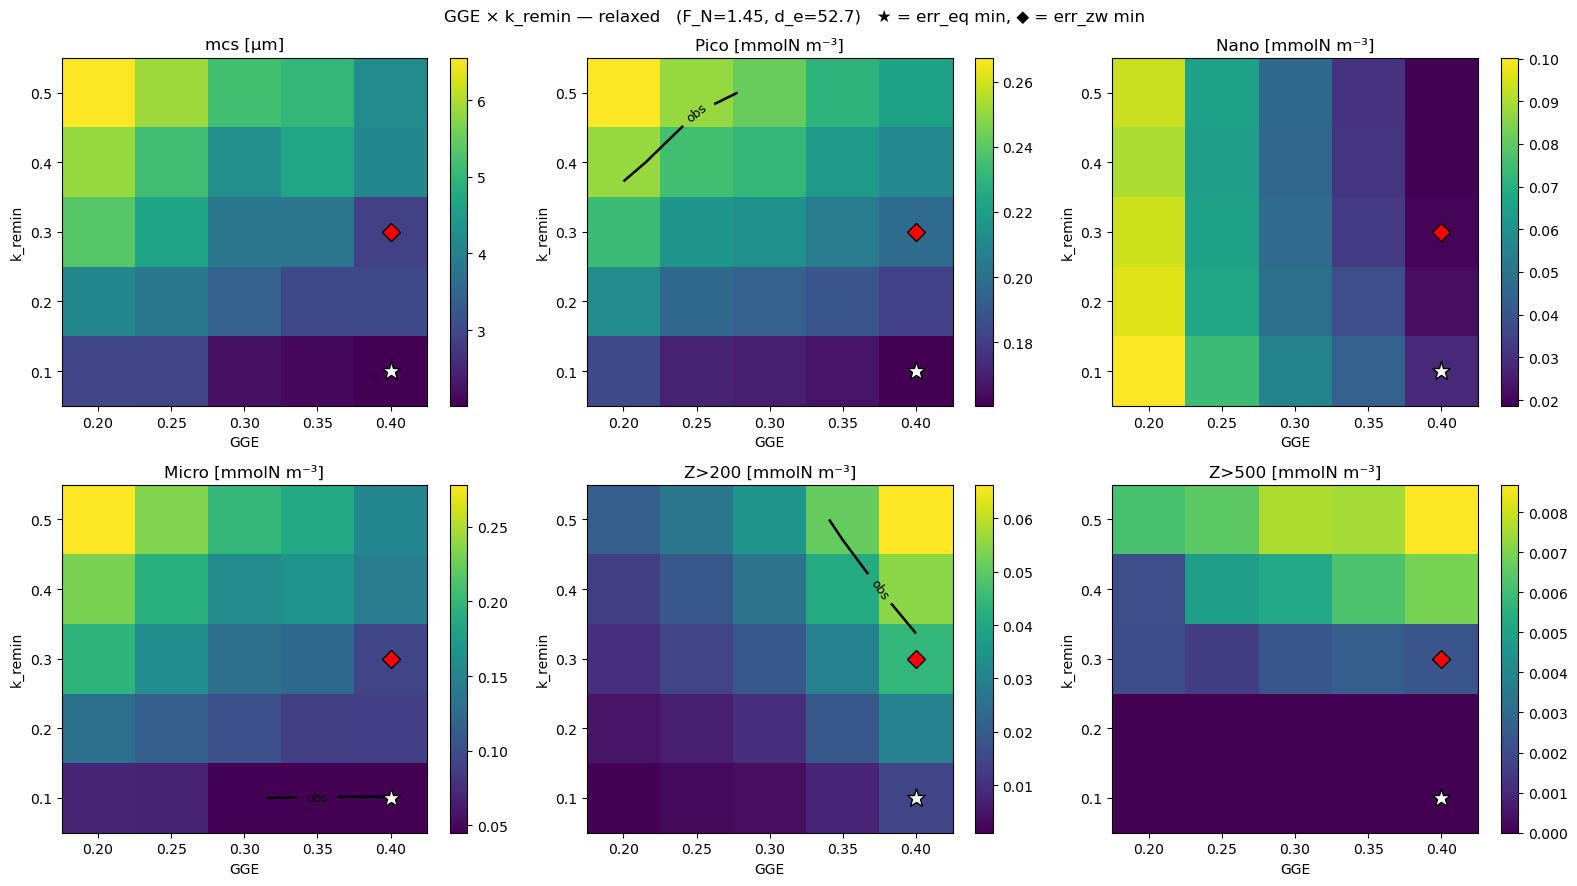

In [28]:
# ── Cell J — 2D scan: GGE × k_remin (xarray-correct; NOT in param_scans) ─────
import xarray as xr
from xso.parscans import run_xso_parscan

PARAM1, AXIS1 = 'GrazingRouter__gge',     np.array([0.20, 0.25, 0.30, 0.35, 0.40])
PARAM2, AXIS2 = 'DetritusRemin__k_remin', np.array([0.10, 0.20, 0.30, 0.40, 0.50])
TAIL_AVG    = 1000
mP_baseline = np.full(len(phyto_esd), 0.02)

TARGETS = ['mcs', 'P_pico', 'P_nano', 'P_micro', 'Z_gt200', 'Z_gt500']
W_EQ    = {k: 1.0 for k in TARGETS}
W_ZWT   = {**W_EQ, 'Z_gt200': 2.0, 'Z_gt500': 2.0}

# Sieburth weights as a labelled DataArray — phyto dim aligns by name on multiply
W_da = xr.DataArray(W_PHYTO, dims=('bin', 'phyto'),
                    coords={'bin': ['Pico', 'Nano', 'Micro'],
                            'phyto': phyto_esd})
geomeans_da = xr.DataArray(GEOMEANS, dims='bin',
                           coords={'bin': ['Pico', 'Nano', 'Micro']})

gge_kremin_scan = {}

for r in regimes:
    d_e = float(targets[r]['forcing']['Inflow__de'])
    o   = obs_refs[r]
    overrides = {**targets[r]['forcing'],
                 'PhytoMortality__rate': mP_baseline}
    scan = run_xso_parscan(
        model_file_name='cariaco_npzd_setups',
        model_name='model_npzd',
        model_setup_name='model_setup_npzd_tani',
        param_name=PARAM1,  param_values=AXIS1,
        param_name2=PARAM2, param_values2=AXIS2,
        fixed_overrides=overrides,
        postprocess_name='avg_tail',
        postprocess_kwargs={'avg_window': TAIL_AVG},
        processes=8,
    )

    # ── derived metrics as DataArrays (everything aligns by named dim) ───────
    P_da     = scan['Phytoplankton__biomass'].squeeze('time')
    Z_da     = scan['Zooplankton__biomass'].squeeze('time')
    N_da     = scan['Nutrient__value'].squeeze('time')
    D_da     = scan['Detritus__value'].squeeze('time')
    PPpc_da  = scan['Growth__uptake_value'].squeeze('time')
    expv_da  = scan['DetritusSink__sinking_value'].squeeze('time')

    sumP_da = P_da.sum(dim='phyto')
    sumZ_da = Z_da.sum(dim='zoo')

    bins_da    = (W_da * P_da).sum(dim='phyto')          # dims: (bin, PARAM1, PARAM2) or similar
    P_pico_da  = bins_da.sel(bin='Pico')
    P_nano_da  = bins_da.sel(bin='Nano')
    P_micro_da = bins_da.sel(bin='Micro')

    frac_da = bins_da / bins_da.sum(dim='bin').clip(min=1e-30)
    mcs_da  = 10.0 ** ((frac_da * np.log10(geomeans_da)).sum(dim='bin'))

    Z_gt200_da = Z_da.where(scan['zoo'] > 200, 0).sum(dim='zoo')
    Z_gt500_da = Z_da.where(scan['zoo'] > 500, 0).sum(dim='zoo')

    PP_da     = PPpc_da.sum(dim='phyto')
    Export_da = expv_da * d_e

    # ── extract consistent (n_GGE, n_kremin) numpy arrays for downstream ─────
    def _arr(da):
        return da.transpose(PARAM1, PARAM2).values

    GGE = scan[PARAM1].values        # already 1D coord
    KR  = scan[PARAM2].values
    mcs     = _arr(mcs_da)
    P_pico  = _arr(P_pico_da);  P_nano = _arr(P_nano_da);  P_micro = _arr(P_micro_da)
    sumP    = _arr(sumP_da);    sumZ   = _arr(sumZ_da)
    Z_gt200 = _arr(Z_gt200_da); Z_gt500= _arr(Z_gt500_da)
    N       = _arr(N_da);       D      = _arr(D_da)
    PP      = _arr(PP_da);      Export = _arr(Export_da)

    ts = dict(mcs=mcs, P_pico=P_pico, P_nano=P_nano, P_micro=P_micro,
              Z_gt200=Z_gt200, Z_gt500=Z_gt500)

    def _joint_err(weights):
        num = np.zeros(mcs.shape); wsum = 0.0
        for k in TARGETS:
            if np.isfinite(o[k]) and o[k] > 0:
                num  = num + weights[k] * ((ts[k] - o[k]) / o[k]) ** 2
                wsum = wsum + weights[k]
        return np.sqrt(num / wsum)

    err_eq = _joint_err(W_EQ)
    err_zw = _joint_err(W_ZWT)

    gge_kremin_scan[r] = dict(
        GGE=GGE, kremin=KR, mcs=mcs,
        P_pico=P_pico, P_nano=P_nano, P_micro=P_micro,
        sumP=sumP, Z_gt200=Z_gt200, Z_gt500=Z_gt500, sumZ=sumZ,
        N=N, D=D, PP=PP, Export=Export,
        err_eq=err_eq, err_zw=err_zw,
    )

    # ── print: baseline (named lookup) + top-5 by each error ─────────────────
    def _row(i, j, label):
        return (f"{label:>6} {GGE[i]:6.2f} {KR[j]:7.2f}  {mcs[i,j]:6.2f} "
                f"{P_pico[i,j]:7.3f} {P_nano[i,j]:7.3f} {P_micro[i,j]:7.3f} "
                f"{Z_gt200[i,j]:7.4f} {Z_gt500[i,j]:7.4f} "
                f"{err_eq[i,j]:7.3f} {err_zw[i,j]:7.3f}")

    i_base = int(np.argmin(np.abs(GGE - 0.25)))
    j_base = int(np.argmin(np.abs(KR  - 0.10)))

    print(f"\n=== {r.upper()} — GGE × k_remin   "
          f"(F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
          f"d_e={targets[r]['forcing']['Inflow__de']:.1f}) ===")
    print(f"{'rank':>6} {'GGE':>6} {'k_remin':>7}  {'mcs':>6} "
          f"{'Pico':>7} {'Nano':>7} {'Micro':>7} "
          f"{'Z>200':>7} {'Z>500':>7} {'err_eq':>7} {'err_zw':>7}")
    print(_row(i_base, j_base, 'base'))
    print(f"{'obs':>6} {'-':>6} {'-':>7}  {o['mcs']:6.2f} "
          f"{o['P_pico']:7.3f} {o['P_nano']:7.3f} {o['P_micro']:7.3f} "
          f"{o['Z_gt200']:7.4f} {o['Z_gt500']:7.4f}  {'-':>6}  {'-':>6}")

    for label, err in [('Top-5 equal-weighted err_eq', err_eq),
                       ('Top-5 Z-weighted err_zw',     err_zw)]:
        print(f"\n{label}:")
        flat_idx = np.argsort(err.ravel())[:5]
        for rank, k in enumerate(flat_idx, start=1):
            ii, jj = np.unravel_index(k, err.shape)
            print(_row(ii, jj, f"#{rank}"))

    # ── plot: 6-panel heatmap; black contour at obs; minima marked ───────────
    i_eq, j_eq = np.unravel_index(np.nanargmin(err_eq), err_eq.shape)
    i_zw, j_zw = np.unravel_index(np.nanargmin(err_zw), err_zw.shape)

    panels = [('mcs [µm]',          mcs,      o['mcs']),
              ('Pico [mmolN m⁻³]',  P_pico,   o['P_pico']),
              ('Nano [mmolN m⁻³]',  P_nano,   o['P_nano']),
              ('Micro [mmolN m⁻³]', P_micro,  o['P_micro']),
              ('Z>200 [mmolN m⁻³]', Z_gt200,  o['Z_gt200']),
              ('Z>500 [mmolN m⁻³]', Z_gt500,  o['Z_gt500'])]

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(f"GGE × k_remin — {r}   "
                 f"(F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
                 f"d_e={targets[r]['forcing']['Inflow__de']:.1f})   "
                 f"★ = err_eq min, ◆ = err_zw min")
    for ax, (title, data, ov) in zip(axes.flat, panels):
        # data shape (n_GGE, n_kremin); pcolormesh wants C as (n_Y, n_X)
        pc = ax.pcolormesh(GGE, KR, data.T, shading='auto', cmap='viridis')
        fig.colorbar(pc, ax=ax)
        if np.isfinite(ov) and (data.min() <= ov <= data.max()):
            cs = ax.contour(GGE, KR, data.T, levels=[ov], colors='k', linewidths=1.8)
            ax.clabel(cs, fmt={ov: 'obs'}, fontsize=9, inline=True)
        ax.plot(GGE[i_eq], KR[j_eq], '*', color='white', mec='black', ms=14)
        ax.plot(GGE[i_zw], KR[j_zw], 'D', color='red',   mec='black', ms=9)
        ax.set_xlabel('GGE'); ax.set_ylabel('k_remin'); ax.set_title(title)
    plt.tight_layout(); plt.show()

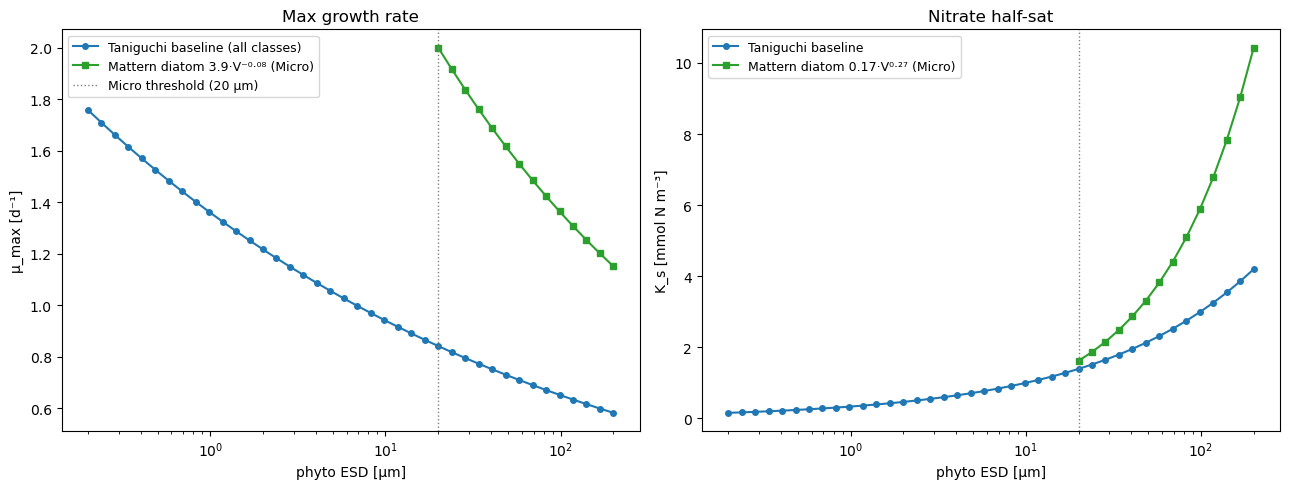

In [29]:
# ── Cell K1 — Mattern diatom allometry curves (visualisation only) ───────────
# Taniguchi baseline μ_max & K_s across full phyto range; Mattern's diatom
# formulae overlaid on the Micro band (ESD >= 20 µm).
V_phyto = (np.pi / 6.0) * phyto_esd ** 3       # µm³ from ESD

mu_tani = 1.36 * phyto_esd ** (-0.16)          # Taniguchi μ_max, d⁻¹
ks_tani = 0.33 * phyto_esd ** ( 0.48)          # Taniguchi K_s,    mmol N m⁻³

mu_mattern_diatom = 3.9  * V_phyto ** (-0.08)  # Mattern diatom μ_max, d⁻¹
ks_mattern_diatom = 0.17 * V_phyto ** ( 0.27)  # Mattern diatom K_NO3, mmol N m⁻³

micro = phyto_esd >= 20.0

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(phyto_esd, mu_tani, '-o', color='C0', label='Taniguchi baseline (all classes)', ms=4)
ax.plot(phyto_esd[micro], mu_mattern_diatom[micro], '-s', color='C2',
        label='Mattern diatom 3.9·V⁻⁰·⁰⁸ (Micro)', ms=5)
ax.axvline(20.0, color='gray', ls=':', lw=1, label='Micro threshold (20 µm)')
ax.set_xscale('log')                             # log size axis (conventional)
ax.set_xlabel('phyto ESD [µm]'); ax.set_ylabel('μ_max [d⁻¹]')
ax.set_title('Max growth rate'); ax.legend(fontsize=9)

ax = axes[1]
ax.plot(phyto_esd, ks_tani, '-o', color='C0', label='Taniguchi baseline', ms=4)
ax.plot(phyto_esd[micro], ks_mattern_diatom[micro], '-s', color='C2',
        label='Mattern diatom 0.17·V⁰·²⁷ (Micro)', ms=5)
ax.axvline(20.0, color='gray', ls=':', lw=1)
ax.set_xscale('log')
ax.set_xlabel('phyto ESD [µm]'); ax.set_ylabel('K_s [mmol N m⁻³]')
ax.set_title('Nitrate half-sat'); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

In [30]:
# ── Cell K2 — Test A: μ_max-only diatom boost (K_s unchanged) ────────────────
# Apply Mattern's diatom μ_max formula to phyto classes with ESD ≥ 20 µm;
# everything else (K_s included) stays at baseline.
V_phyto = (np.pi / 6.0) * phyto_esd ** 3
micro   = phyto_esd >= 20.0
TAIL    = 1000

mu_baseline = 1.36 * phyto_esd ** (-0.16)
mu_diatom_A = mu_baseline.copy()
mu_diatom_A[micro] = 3.9 * V_phyto[micro] ** (-0.08)

ks_baseline = 0.33 * phyto_esd ** (0.48)
mP_baseline = np.full(len(phyto_esd), 0.02)

def _single_metrics(out, d_e):
    T = out.isel(time=slice(-TAIL, None))
    P = T['Phytoplankton__biomass'].mean('time').values
    Z = T['Zooplankton__biomass'].mean('time').values
    bins = P @ W_PHYTO.T
    frac = bins / max(bins.sum(), 1e-30)
    return dict(
        mcs    = float(10.0 ** (frac @ np.log10(GEOMEANS))),
        P_pico = float(bins[0]), P_nano = float(bins[1]), P_micro = float(bins[2]),
        sumP   = float(P.sum()),
        Z_gt200= float(Z[M_Z200].sum()),
        Z_gt500= float(Z[M_Z500].sum()),
        sumZ   = float(Z.sum()),
        N      = float(T['Nutrient__value'].mean('time')),
        D      = float(T['Detritus__value'].mean('time')),
        PP     = float(T['Growth__uptake_value'].mean('time').sum()),
        Export = float(T['DetritusSink__sinking_value'].mean('time')) * d_e,
    )

f3 = lambda v: f"{v:7.3f}" if np.isfinite(v) else f"{'-':>7}"
f4 = lambda v: f"{v:7.4f}" if np.isfinite(v) else f"{'-':>7}"
fm = lambda v: f"{v:6.2f}" if np.isfinite(v) else f"{'-':>6}"

def _row(label, m):
    return (f"{label:>8} {fm(m['mcs'])} {f3(m['P_pico'])} {f3(m['P_nano'])} "
            f"{f3(m['P_micro'])} {f3(m['sumP'])} {f4(m['Z_gt200'])} "
            f"{f4(m['Z_gt500'])} {f3(m['sumZ'])} {f3(m['N'])} {f3(m['D'])} "
            f"{f3(m['PP'])} {f3(m['Export'])}")

for r in regimes:
    d_e = float(targets[r]['forcing']['Inflow__de'])
    base_over = {**targets[r]['forcing'],
                 'PhytoMortality__rate':  mP_baseline,
                 'Growth__mu_max':        mu_baseline,
                 'Growth__halfsat':       ks_baseline}
    diat_over = {**targets[r]['forcing'],
                 'PhytoMortality__rate':  mP_baseline,
                 'Growth__mu_max':        mu_diatom_A,
                 'Growth__halfsat':       ks_baseline}
    base = _single_metrics(pu.run_single_point(cns.model_npzd, cns.model_setup_npzd_tani,
                                               scan_params={}, fixed_overrides=base_over), d_e)
    diat = _single_metrics(pu.run_single_point(cns.model_npzd, cns.model_setup_npzd_tani,
                                               scan_params={}, fixed_overrides=diat_over), d_e)
    o = obs_refs[r]
    o_metrics = dict(mcs=o['mcs'], P_pico=o['P_pico'], P_nano=o['P_nano'],
                     P_micro=o['P_micro'], sumP=o['sumP'],
                     Z_gt200=o['Z_gt200'], Z_gt500=o['Z_gt500'],
                     sumZ=np.nan, N=o['N'], D=np.nan, PP=o['PP'], Export=o['Export'])

    print(f"\n=== TEST A — {r.upper()}  (F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
          f"d_e={d_e:.1f}) — μ_max diatom boost on Micro (K_s baseline) ===")
    print(f"{'config':>8} {'mcs':>6} {'Pico':>7} {'Nano':>7} {'Micro':>7} "
          f"{'ΣP':>7} {'Z>200':>7} {'Z>500':>7} {'ΣZ':>7} "
          f"{'N':>7} {'D':>7} {'PP':>7} {'Exp':>7}")
    print(_row('baseline',  base))
    print(_row('+diatom_A', diat))
    print(_row('obs',       o_metrics))


=== TEST A — UPWELLING  (F_N=2.58, d_e=42.8) — μ_max diatom boost on Micro (K_s baseline) ===
  config    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
baseline   5.11   0.237   0.081   0.191   0.509  0.0141  0.0024   0.211   0.084   0.497   0.140   2.484
+diatom_A   9.43   0.221   0.112   0.339   0.672  0.0573  0.0178   0.232   0.080   0.493   0.138   2.464
     obs   4.84   0.224   0.137   0.192   0.583  0.0835  0.0506       -   2.006       -   0.295   3.192

=== TEST A — RELAXED  (F_N=1.45, d_e=52.7) — μ_max diatom boost on Micro (K_s baseline) ===
  config    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
baseline   2.94   0.171   0.074   0.068   0.313  0.0027  0.0000   0.136   0.046   0.280   0.070   1.401
+diatom_A   7.81   0.164   0.090   0.207   0.462  0.0235  0.0049   0.141   0.042   0.279   0.069   1.397
     obs   2.01   0.246   0.111   0.046   0.436  0.0479  0.0233       -   0.654   

In [31]:
# ── Cell K3 — Test B: μ_max + K_s diatom modification on Micro ───────────────
# Apply Mattern's diatom formulas for BOTH μ_max and K_NO3 on classes ≥ 20 µm.
V_phyto = (np.pi / 6.0) * phyto_esd ** 3
micro   = phyto_esd >= 20.0
TAIL    = 1000

mu_baseline = 1.36 * phyto_esd ** (-0.16)
mu_diatom   = mu_baseline.copy()
mu_diatom[micro] = 3.9 * V_phyto[micro] ** (-0.08)

ks_baseline = 0.33 * phyto_esd ** (0.48)
ks_diatom   = ks_baseline.copy()
ks_diatom[micro] = 0.17 * V_phyto[micro] ** (0.27)

mP_baseline = np.full(len(phyto_esd), 0.02)

# reuse the _single_metrics, _row, formatters from K2 (same notebook scope)

for r in regimes:
    d_e = float(targets[r]['forcing']['Inflow__de'])
    base_over = {**targets[r]['forcing'],
                 'PhytoMortality__rate':  mP_baseline,
                 'Growth__mu_max':        mu_baseline,
                 'Growth__halfsat':       ks_baseline}
    diat_over = {**targets[r]['forcing'],
                 'PhytoMortality__rate':  mP_baseline,
                 'Growth__mu_max':        mu_diatom,
                 'Growth__halfsat':       ks_diatom}
    base = _single_metrics(pu.run_single_point(cns.model_npzd, cns.model_setup_npzd_tani,
                                               scan_params={}, fixed_overrides=base_over), d_e)
    diat = _single_metrics(pu.run_single_point(cns.model_npzd, cns.model_setup_npzd_tani,
                                               scan_params={}, fixed_overrides=diat_over), d_e)
    o = obs_refs[r]
    o_metrics = dict(mcs=o['mcs'], P_pico=o['P_pico'], P_nano=o['P_nano'],
                     P_micro=o['P_micro'], sumP=o['sumP'],
                     Z_gt200=o['Z_gt200'], Z_gt500=o['Z_gt500'],
                     sumZ=np.nan, N=o['N'], D=np.nan, PP=o['PP'], Export=o['Export'])

    print(f"\n=== TEST B — {r.upper()}  (F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
          f"d_e={d_e:.1f}) — μ_max + K_s diatom on Micro ===")
    print(f"{'config':>8} {'mcs':>6} {'Pico':>7} {'Nano':>7} {'Micro':>7} "
          f"{'ΣP':>7} {'Z>200':>7} {'Z>500':>7} {'ΣZ':>7} "
          f"{'N':>7} {'D':>7} {'PP':>7} {'Exp':>7}")
    print(_row('baseline',  base))
    print(_row('+diatom_B', diat))
    print(_row('obs',       o_metrics))


=== TEST B — UPWELLING  (F_N=2.58, d_e=42.8) — μ_max + K_s diatom on Micro ===
  config    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
baseline   5.11   0.237   0.081   0.191   0.509  0.0141  0.0024   0.211   0.084   0.497   0.140   2.484
+diatom_B   6.02   0.225   0.087   0.215   0.527  0.0385  0.0050   0.227   0.087   0.494   0.139   2.469
     obs   4.84   0.224   0.137   0.192   0.583  0.0835  0.0506       -   2.006       -   0.295   3.192

=== TEST B — RELAXED  (F_N=1.45, d_e=52.7) — μ_max + K_s diatom on Micro ===
  config    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
baseline   2.94   0.171   0.074   0.068   0.313  0.0027  0.0000   0.136   0.046   0.280   0.070   1.401
+diatom_B   5.51   0.166   0.077   0.143   0.386  0.0153  0.0000   0.140   0.045   0.279   0.069   1.397
     obs   2.01   0.246   0.111   0.046   0.436  0.0479  0.0233       -   0.654       -   0.181   1.398
